# Interpretación clínica de la atención promedio del predictor de BIS ante trenes de pulsos de propofol y remifentanilo

En esta libreta se analiza la atención del Bloque C del modelo `ModeloAnestesia` ante un protocolo de 130 min compuesto por dos trenes de pulsos rectangulares de 35 s cada 10 min:

| Intervalo [min] | Entrada |
|---|---|
| 0 – 40   | Solo propofol |
| 40 – 60  | Propofol y remifentanilo (trenes traslapados) |
| 60 – 100 | Solo remifentanilo |
| 100 – 130 | Sin infusión |

**Objeto de análisis: la atención promedio.** En la atención multicabeza interpretable, las matrices de las $H$ cabezas se promedian *antes* de ponderar los valores, que son compartidos:
$$A^{(h)} = \mathrm{softmax}\!\left(\frac{(z W_Q^{(h)})(z W_K^{(h)})^{\top}}{\sqrt{d_h}}\right), \qquad \bar{A} = \frac{1}{H}\sum_{h=1}^{H} A^{(h)}, \qquad \mathrm{salida} = \bar{A}\,(z W_V)\,W_H .$$
Por ello, $\bar{A}$ no es un resumen de las cabezas, sino la matriz de atención que efectivamente emplea el modelo; en consecuencia, todo el análisis se realiza sobre $\bar{A}$. Además, dado que $\beta_t$ corresponde a la última fila de la salida de la atención, la información relevante para la predicción del BIS en $t+1$ se encuentra en la fila de la última consulta, $\bar{A}_{T-1,\,j}$.

**Procedimiento.** Las señales se someten al mismo preprocesamiento empleado en el entrenamiento (bloques de 10 s, relleno con ceros y normalización por ventana) y se recorren con una ventana deslizante de $T = 180$ pasos (30 min). La matriz $\bar{A}$ se obtiene mediante un *forward hook* sobre `modelo.atencion`.

**Magnitudes de lectura clínica.** Para cada instante $t$ se calculan:
* $\Delta\mathrm{BIS}(t)$: diferencia entre el BIS predicho y el que predice el modelo con una ventana sin infusión y el mismo contexto de paciente.
* **Horizonte de la atención:** retraso medio de la atención, $\bar{\ell}(t) = \sum_j \bar{A}_{T-1,j}\,\ell_j$, y retraso que acumula el 50 % de la atención. Indican cuánto del pasado considera el modelo al estimar el BIS.
* **Atención relativa sobre el bolo** y **sobre el periodo posterior al bolo:** masa de atención asignada a los instantes de infusión, o a los minutos siguientes a ella, dividida entre la que asigna la ventana sin infusión a esas mismas posiciones. Un valor mayor que uno indica que el modelo privilegia ese periodo por su contenido y no por su posición en la ventana.

**Observaciones.**
* Cada ventana abarca 30 min, por lo que contiene hasta tres pulsos consecutivos de un mismo tren.
* En el intervalo traslapado los pulsos de ambos fármacos son simultáneos; la atención, que opera sobre instantes de tiempo, no puede separar la contribución de cada fármaco en ese intervalo.


In [1]:
# =============================================================================
# CONFIGURACIÓN
# =============================================================================
import os

# Carpeta que contiene Modelo_Predictor_BIS.py
CARPETA_MODELO   = r"C:\Users\yordi\Desktop\Libretas Python"

# Pesos entrenados (state_dict guardado por la libreta de entrenamiento)
RUTA_PESOS       = r"C:\Users\yordi\Desktop\modeloBIS.pt"

# Conjunto de prueba: de él se toman las covariables y el historial BIS
RUTA_PT_PRUEBA   = r"C:\Users\yordi\Desktop\dataset_prueba.pt"

# Contexto del paciente para el análisis principal. Con None se selecciona
# automáticamente una muestra a la mitad del registro del paciente indicado,
# con historial de BIS completo (sin relleno de ceros).
INDICE_MUESTRA     = None
PACIENTE_REFERENCIA = 0         # Posición del paciente en el conjunto de prueba
BIS_MINIMO_VALIDO   = 20        # Una ventana es válida si todo su BIS crudo supera este umbral

# Si es True y no se encuentran los pesos, se continúa con pesos aleatorios
# (útil únicamente para comprobar que la libreta se ejecuta sin errores).
PERMITIR_PESOS_ALEATORIOS = False

# --- Ventana del modelo y muestreo (deben coincidir con el preprocesamiento) ---
TAMANIYO_VENTANA  = 180         # Pasos por ventana
PERIODO_MUESTREO  = 10          # Segundos por paso (TAMANO_BLOQUE de la limpieza)

# --- Protocolo ---
DURACION_TOTAL_MIN = 130        # Duración total del experimento [min]
DURACION_PULSO_S   = 35         # Duración de cada pulso [s]
PERIODO_PULSOS_MIN = 10         # Separación entre inicios de pulsos consecutivos [min]

# Cada tren se define por el fármaco, el canal de entrada, el intervalo en que
# se aplican los pulsos [inicio, fin) en minutos y la altura de los pulsos.
# La altura se expresa en las unidades de PPF20_RATE / RFTN20_RATE; debido a la
# normalización por ventana, su valor no altera la entrada del modelo.
TRENES = [
    {"farmaco": "Propofol",      "canal": 0, "inicio_min": 0,  "fin_min": 60,  "altura": 0.25},
    {"farmaco": "Remifentanilo", "canal": 1, "inicio_min": 40, "fin_min": 100, "altura": 0.25},
]

# Duración del periodo posterior al bolo considerado en la lectura clínica [min]
VENTANA_POST_BOLO_MIN = 5

# Tratamiento del historial BIS:
#   "fijo"         : misma ventana de historial en todos los instantes (W0..W3
#                    constantes; las diferencias se deben solo a las infusiones).
#   "realimentado" : el historial se forma con las predicciones previas del
#                    modelo, normalizando cada ventana como en el entrenamiento.
MODO_HISTORIAL_BIS = "fijo"

# Número de ventanas procesadas simultáneamente
TAMANIYO_LOTE = 256

# Minutos posteriores al fin del pulso en que termina cada ventana de detalle
RETRASO_VENTANA_DETALLE_MIN = 1

# Carpeta de salida de las figuras
CARPETA_FIGURAS = os.path.join(CARPETA_MODELO, "figuras_atencion_clinica")
os.makedirs(CARPETA_FIGURAS, exist_ok=True)


In [2]:
# =============================================================================
# IMPORTACIONES Y CARGA DEL MODELO
# =============================================================================
import sys
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import PowerNorm

sys.path.insert(0, CARPETA_MODELO)
from Modelo_Predictor_BIS import ModeloAnestesia

dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo = ModeloAnestesia().to(dispositivo)

if os.path.exists(RUTA_PESOS):
    estado = torch.load(RUTA_PESOS, map_location=dispositivo, weights_only=True)
    modelo.load_state_dict(estado)
    print(f"[INFO] Pesos cargados desde {RUTA_PESOS}")
elif PERMITIR_PESOS_ALEATORIOS:
    print("[AVISO] No se encontraron los pesos; se emplean pesos aleatorios.")
else:
    raise FileNotFoundError(f"No se encontró el archivo de pesos: {RUTA_PESOS}")

# El modo de evaluación desactiva el dropout y fija las estadísticas de BatchNorm
modelo.eval()
H = modelo.atencion.num_cabezas
T = TAMANIYO_VENTANA
print(f"[INFO] Dispositivo: {dispositivo} | Cabezas: {H} | Ventana: {T} pasos "
      f"= {T * PERIODO_MUESTREO / 60:.0f} min")


[INFO] Pesos cargados desde C:\Users\yordi\Desktop\modeloBIS.pt
[INFO] Dispositivo: cuda | Cabezas: 4 | Ventana: 180 pasos = 30 min


## Réplica del preprocesamiento de entrenamiento

Las entradas sintéticas se someten exactamente a las mismas transformaciones que los datos con los que se entrenó el modelo (`Procesar_y_limpiar_datos.ipynb` y `Crea_tensores_pytorch.ipynb`):

1. **Remuestreo a bloques de 10 s.** Las tasas de infusión se construyen con resolución de 1 s y se promedian en bloques de `PERIODO_MUESTREO` segundos; un pulso de 35 s ocupa, por tanto, tres bloques completos y un bloque a la mitad de su altura.
2. **Relleno con ceros** de los instantes anteriores al inicio del registro.
3. **Normalización por ventana:** cada ventana y cada canal se normalizan con su propia media y desviación estándar, $\tilde{x} = (x - \mu_w)/\sigma_w$; si $\sigma_w < 10^{-8}$, únicamente se centra la ventana. Finalmente se aplica el redondeo a `float16` empleado al almacenar los tensores.

**Consecuencia importante.** La normalización por ventana hace que la entrada sea invariante ante cualquier cambio de escala y de nivel de cada canal dentro de la ventana. En particular, la altura de los pulsos no modifica el resultado, y una infusión constante de cualquier magnitud es indistinguible de la ausencia de infusión (ambas producen una ventana nula). Esta propiedad se verifica numéricamente más adelante.


In [3]:
# =============================================================================
# RÉPLICA DEL PREPROCESAMIENTO DE ENTRENAMIENTO
# =============================================================================
def remuestrear_bloques(senal_1s, tam_bloque=None):
    """
    Promedia una señal muestreada cada 1 s en bloques de 'tam_bloque' segundos,
    de forma equivalente a la tasa media por bloque del preprocesamiento.
    El último bloque puede ser incompleto y se promedia con las muestras disponibles.

    senal_1s : (C, N_1s)  →  (C, ceil(N_1s / tam_bloque))
    """
    tam_bloque = int(PERIODO_MUESTREO) if tam_bloque is None else tam_bloque
    C, N = senal_1s.shape
    n_bloques = int(np.ceil(N / tam_bloque))
    relleno = np.full((C, n_bloques * tam_bloque - N), np.nan, dtype=np.float32)
    ext = np.concatenate([senal_1s.astype(np.float32), relleno], axis=1)
    return np.nanmean(ext.reshape(C, n_bloques, tam_bloque), axis=2).astype(np.float32)


def normalizar_ventanas(v):
    """
    Normaliza cada ventana con su propia media y desviación estándar a lo
    largo de la última dimensión (misma regla que 'normalizar_ventana').
    Se aplica además el redondeo a float16 con el que se guardaron los tensores.
    """
    v = v.float()
    media = v.mean(dim=-1, keepdim=True)
    desv  = v.std(dim=-1, unbiased=False, keepdim=True)
    constante = desv < 1e-8
    salida = torch.where(constante, v - media, (v - media) / torch.where(constante, torch.ones_like(desv), desv))
    return salida.half().float()


def ventanas_de(senal):
    """
    Genera todas las ventanas normalizadas (N, C, T) a partir de la señal en
    bloques (C, N). La ventana k termina en el paso k; los instantes previos
    al inicio se rellenan con ceros antes de normalizar, como en el entrenamiento.
    """
    senal = torch.as_tensor(senal, dtype=torch.float32)
    relleno = torch.zeros(senal.shape[0], T - 1)
    senal_ext = torch.cat([relleno, senal], dim=1)
    crudas = senal_ext.unfold(1, T, 1).permute(1, 0, 2)          # (N, C, T)
    return normalizar_ventanas(crudas)


def masa_intervalo(filas, p0, p1):
    """
    Masa de atención que la última consulta de cada ventana asigna a los
    instantes absolutos [p0, p1).

    filas : (N, T) o (N, H, T), donde la ventana k abarca los pasos k-T+1 … k.
    Retorna (N,) o (N, H).
    """
    N = filas.shape[0]
    inicio_abs = np.arange(N) - T + 1
    j0 = np.clip(p0 - inicio_abs, 0, T)
    j1 = np.clip(p1 - inicio_abs, 0, T)
    acumulada = np.concatenate([np.zeros(filas.shape[:-1] + (1,)), np.cumsum(filas, axis=-1)], axis=-1)
    forma = (N,) + (1,) * (filas.ndim - 1)
    idx0 = np.broadcast_to(j0.reshape(forma), filas.shape[:-1] + (1,))
    idx1 = np.broadcast_to(j1.reshape(forma), filas.shape[:-1] + (1,))
    return (np.take_along_axis(acumulada, idx1, -1) - np.take_along_axis(acumulada, idx0, -1))[..., 0]


def fraccion_uniforme(N, p0, p1):
    """Masa que asignaría una atención uniforme al intervalo [p0, p1) en cada ventana."""
    inicio_abs = np.arange(N) - T + 1
    return (np.clip(p1 - inicio_abs, 0, T) - np.clip(p0 - inicio_abs, 0, T)) / T


## Extracción de la atención mediante un *forward hook*

La función recalcula la matriz de cada cabeza con las matrices $W_Q^{(h)}$ y $W_K^{(h)}$ entrenadas y devuelve su promedio $\bar{A}$. En modo `eval()` el *dropout* es la identidad, por lo que la matriz recalculada coincide con la empleada en la inferencia (se verifica numéricamente). Para el recorrido completo se conserva únicamente la fila de la última consulta.

In [4]:
# =============================================================================
# EXTRACCIÓN DE LA ATENCIÓN
# =============================================================================
def extraer_atencion(modelo, infusiones, bis_hist, covariables,
                     solo_ultima_fila=False, verificar=False):
    """
    Ejecuta la inferencia y captura la atención de cada cabeza mediante un
    forward hook sobre modelo.atencion.

    Retorna un diccionario con:
        bis_pred   : (B,)
        bis_pseudo : (B, T)
        cabezas    : (B, H, T, T)  o bien (B, H, T) si solo_ultima_fila=True
        promedio   : (B, T, T)     o bien (B, T)
        error_max  : discrepancia máxima de la reconstrucción (si verificar=True)
    """
    capturas = {}

    def gancho(modulo, entradas, salida):
        Q, K, V = entradas
        # Cuando solo interesa la última consulta se proyecta únicamente esa fila
        Q_uso = Q[:, -1:, :] if solo_ultima_fila else Q
        cabezas = []
        for h in range(modulo.num_cabezas):
            puntajes = torch.bmm(
                modulo.pesos_Q[h](Q_uso),
                modulo.pesos_K[h](K).transpose(1, 2)
            ) / modulo.escala
            cabezas.append(torch.softmax(puntajes, dim=-1))
        cabezas  = torch.stack(cabezas, dim=1)          # (B, H, Tq, T)
        promedio = cabezas.mean(dim=1)                  # (B, Tq, T)

        # Verificación: la salida reconstruida debe coincidir con la del módulo
        if verificar and not solo_ultima_fila:
            reconstruida = modulo.pesos_WH(torch.bmm(promedio, modulo.pesos_V(V)))
            capturas["error_max"] = (reconstruida - salida).abs().max().item()

        if solo_ultima_fila:
            cabezas, promedio = cabezas[:, :, 0, :], promedio[:, 0, :]
        capturas.update(cabezas=cabezas, promedio=promedio)

    manejador = modelo.atencion.register_forward_hook(gancho)
    try:
        with torch.no_grad():
            bis_pred, bis_pseudo = modelo(infusiones, bis_hist, covariables)
    finally:
        manejador.remove()

    capturas.update(bis_pred=bis_pred, bis_pseudo=bis_pseudo)
    return capturas


## Contexto del paciente

Además de las infusiones, el modelo recibe las covariables del paciente (edad, peso, altura y sexo) y su historial de BIS de los últimos 30 min. Los pacientes del conjunto de prueba se identifican como bloques consecutivos de muestras con covariables idénticas; de cada uno puede tomarse una muestra representativa situada a la mitad del registro, cuya ventana de BIS no contenga relleno de ceros.

In [5]:
# =============================================================================
# CONTEXTO DEL PACIENTE
# =============================================================================
if not os.path.exists(RUTA_PT_PRUEBA):
    raise FileNotFoundError(f"No se encontró el conjunto de prueba: {RUTA_PT_PRUEBA}")

datos = torch.load(RUTA_PT_PRUEBA, map_location="cpu", weights_only=True)
cov_todas    = datos["covariables"].float()
bis_n_todas  = datos["bis_hist"].float()
bis_gt_todas = datos["bis_hist_gt"].float()
del datos

# Identificación de pacientes: bloques consecutivos con covariables idénticas
cambio  = torch.any(cov_todas[1:] != cov_todas[:-1], dim=1).numpy()
inicios_pac = np.concatenate([[0], np.nonzero(cambio)[0] + 1])
finales_pac = np.concatenate([inicios_pac[1:], [len(cov_todas)]])
print(f"[INFO] Pacientes identificados en el conjunto de prueba: {len(inicios_pac)}")


def indice_representativo(a, b):
    """
    Índice a la mitad del registro [a, b) cuya ventana de BIS no contiene
    relleno ni valores inválidos; retorna None si no existe.
    """
    if b - a < T + 1:
        return None
    centro = a + max(T, (b - a) // 2)
    for desfase in range(0, b - a):
        for idx in (centro + desfase, centro - desfase):
            if a + T - 1 <= idx < b and bis_gt_todas[idx].min() >= BIS_MINIMO_VALIDO:
                return int(idx)
    return None


if INDICE_MUESTRA is None:
    # Se recorre la lista de pacientes a partir del indicado hasta hallar uno elegible
    for p in list(range(PACIENTE_REFERENCIA, len(inicios_pac))) + list(range(PACIENTE_REFERENCIA)):
        idx = indice_representativo(inicios_pac[p], finales_pac[p])
        if idx is not None:
            INDICE_MUESTRA = idx
            break
    if INDICE_MUESTRA is None:
        raise RuntimeError("No se encontró ninguna ventana con historial de BIS completo")

covariables = cov_todas[INDICE_MUESTRA:INDICE_MUESTRA + 1].to(dispositivo)
bis_hist_0  = bis_n_todas[INDICE_MUESTRA:INDICE_MUESTRA + 1].to(dispositivo)
bis_crudo_0 = bis_gt_todas[INDICE_MUESTRA:INDICE_MUESTRA + 1]
paciente_ref = int(np.searchsorted(inicios_pac, INDICE_MUESTRA, side="right") - 1)
print(f"[INFO] Contexto: muestra {INDICE_MUESTRA} (paciente {paciente_ref}) | "
      f"covariables = {np.round(covariables[0].cpu().numpy(), 3)}")
print(f"[INFO] BIS crudo de la ventana de contexto: media = {bis_crudo_0.mean():.1f}, "
      f"mínimo = {bis_crudo_0.min():.1f}, último valor = {bis_crudo_0[0, -1]:.1f}")


[INFO] Pacientes identificados en el conjunto de prueba: 32
[INFO] Contexto: muestra 365 (paciente 0) | covariables = [0.608 0.119 0.209 1.   ]
[INFO] BIS crudo de la ventana de contexto: media = 64.9, mínimo = 61.6, último valor = 66.1


In [6]:
# =============================================================================
# CONSTRUCCIÓN DEL PROTOCOLO
# =============================================================================
N_1S = int(DURACION_TOTAL_MIN * 60)                  # Duración con resolución de 1 s
infusion_1s = np.zeros((2, N_1S), dtype=np.float32)
pulsos = []                                          # (inicio [s], canal, fármaco)

for tren in TRENES:
    ini_s, fin_s, c = int(tren["inicio_min"] * 60), int(tren["fin_min"] * 60), tren["canal"]
    for s0 in range(ini_s, min(fin_s, N_1S), int(PERIODO_PULSOS_MIN * 60)):
        s1 = min(s0 + DURACION_PULSO_S, fin_s, N_1S)   # El pulso no rebasa el fin del tren
        infusion_1s[c, s0:s1] = tren["altura"]
        pulsos.append((s0, c, tren["farmaco"]))

# Señal en bloques de PERIODO_MUESTREO segundos (dominio temporal del modelo)
infusion = remuestrear_bloques(infusion_1s)          # (2, N_PASOS)
N_PASOS  = infusion.shape[1]
tiempo_min = np.arange(N_PASOS) * PERIODO_MUESTREO / 60.0
FARMACOS = {tren["canal"]: tren["farmaco"] for tren in TRENES}

def a_pasos(s0):
    """Intervalo [p0, p1) de pasos (bloques) ocupado por un pulso que inicia en s0 [s]."""
    return int(s0 // PERIODO_MUESTREO), int(np.ceil((s0 + DURACION_PULSO_S) / PERIODO_MUESTREO))

P_DUR  = a_pasos(0)[1] - a_pasos(0)[0]               # Pasos ocupados por un pulso
P_POST = int(VENTANA_POST_BOLO_MIN * 60 / PERIODO_MUESTREO)

# Pulsos por fármaco y agrupación por instante de inicio y fármacos activos
pulsos_por_canal = {c: sorted({a_pasos(s0) for s0, cc, _ in pulsos if cc == c}) for c in FARMACOS}
grupos_pulsos = {}
for s0 in sorted({p[0] for p in pulsos}):
    activos = [p[2] for p in pulsos if p[0] == s0]
    etiqueta = " + ".join(activos) if len(activos) > 1 else f"Solo {activos[0].lower()}"
    grupos_pulsos.setdefault(etiqueta, []).append(a_pasos(s0))
todos_pulsos = sorted({a_pasos(p[0]) for p in pulsos})

# Fases del protocolo (intervalos con el mismo conjunto de trenes activos)
bordes = sorted({0, DURACION_TOTAL_MIN} | {t["inicio_min"] for t in TRENES}
                | {t["fin_min"] for t in TRENES})
bordes = [b for b in bordes if 0 <= b <= DURACION_TOTAL_MIN]
FASES = []
for a, b in zip(bordes[:-1], bordes[1:]):
    activos = [t["farmaco"] for t in TRENES if t["inicio_min"] <= a and b <= t["fin_min"]]
    FASES.append((a, b, " + ".join(activos) if activos else "Sin infusión"))

print(f"[INFO] {N_PASOS} pasos de {PERIODO_MUESTREO} s | cada pulso ocupa {P_DUR} bloques "
      f"(el último, parcialmente) | periodo posterior al bolo: {VENTANA_POST_BOLO_MIN} min")
for a, b, etiqueta in FASES:
    print(f"   Fase {a:>4} – {b:<4} min : {etiqueta}")
for etiqueta, lista in grupos_pulsos.items():
    print(f"   {etiqueta:<28s}: pulsos en los minutos {[round(p0 * PERIODO_MUESTREO / 60, 1) for p0, _ in lista]}")


[INFO] 780 pasos de 10 s | cada pulso ocupa 4 bloques (el último, parcialmente) | periodo posterior al bolo: 5 min
   Fase    0 – 40   min : Propofol
   Fase   40 – 60   min : Propofol + Remifentanilo
   Fase   60 – 100  min : Remifentanilo
   Fase  100 – 130  min : Sin infusión
   Solo propofol               : pulsos en los minutos [0.0, 10.0, 20.0, 30.0]
   Propofol + Remifentanilo    : pulsos en los minutos [40.0, 50.0]
   Solo remifentanilo          : pulsos en los minutos [60.0, 70.0, 80.0, 90.0]


## Verificación de la invariancia ante la altura de los pulsos

Se evalúa el modelo con el protocolo escalado por distintos factores. Si la normalización por ventana se reproduce adecuadamente, las predicciones deben coincidir salvo por el redondeo a `float16`.

In [7]:
ventanas_protocolo = ventanas_de(infusion)
k_prueba = slice(0, N_PASOS, 7)                     # Submuestra de ventanas para abreviar
n = len(range(*k_prueba.indices(N_PASOS)))
with torch.no_grad():
    p_base, _ = modelo(ventanas_protocolo[k_prueba].to(dispositivo),
                       bis_hist_0.expand(n, -1), covariables.expand(n, -1))
    for factor in (0.1, 4.0, 40.0):
        p_esc, _ = modelo(ventanas_de(infusion * factor)[k_prueba].to(dispositivo),
                          bis_hist_0.expand(n, -1), covariables.expand(n, -1))
        print(f"Altura × {factor:>5}: diferencia máxima en el BIS predicho = "
              f"{(p_base - p_esc).abs().max().item():.2e}")


Altura ×   0.1: diferencia máxima en el BIS predicho = 0.00e+00
Altura ×   4.0: diferencia máxima en el BIS predicho = 0.00e+00
Altura ×  40.0: diferencia máxima en el BIS predicho = 0.00e+00


## Recorrido de la ventana deslizante y magnitudes de lectura clínica

In [8]:
# =============================================================================
# RECORRIDO Y MAGNITUDES DERIVADAS
# =============================================================================
def recorrer_fijo(bis_hist_c, cov_c):
    """Recorrido por lotes con el historial BIS fijo; devuelve la última fila de Ā y el BIS predicho."""
    filas, preds = [], []
    for a in range(0, N_PASOS, TAMANIYO_LOTE):
        lote = ventanas_protocolo[a:a + TAMANIYO_LOTE].to(dispositivo)
        B = lote.shape[0]
        r = extraer_atencion(modelo, lote, bis_hist_c.expand(B, -1), cov_c.expand(B, -1),
                             solo_ultima_fila=True)
        filas.append(r["promedio"].cpu())
        preds.append(r["bis_pred"].cpu())
    return torch.cat(filas).numpy(), torch.cat(preds).numpy()


def recorrer_realimentado(bis_crudo_c, cov_c):
    """
    Recorrido paso a paso: el historial BIS crudo se construye con las
    predicciones previas del modelo y cada ventana se normaliza antes de
    ingresar al modelo, igual que en el entrenamiento.
    """
    historial = bis_crudo_c[0].clone()
    filas, preds = [], []
    for k in range(N_PASOS):
        entrada_bis = normalizar_ventanas(historial.unsqueeze(0)).to(dispositivo)
        r = extraer_atencion(modelo, ventanas_protocolo[k:k + 1].to(dispositivo),
                             entrada_bis, cov_c, solo_ultima_fila=True)
        p = r["bis_pred"][0].cpu()
        filas.append(r["promedio"].cpu())
        preds.append(p)
        historial = torch.cat([historial[1:], p.view(1)])      # Desplazamiento FIFO
    return torch.cat(filas).numpy(), torch.stack(preds).numpy()


# Retraso de cada clave respecto del instante actual [min]: clave T-1 → 0 min
RETRASOS_MIN = (T - 1 - np.arange(T)) * PERIODO_MUESTREO / 60.0

def horizonte(filas):
    """Retraso medio de la atención y retraso que acumula el 50 % de ella [min]."""
    medio = filas @ RETRASOS_MIN
    acumulada = np.cumsum(filas[..., ::-1], axis=-1)          # Desde el instante actual hacia atrás
    mediano = np.argmax(acumulada >= 0.5, axis=-1) * PERIODO_MUESTREO / 60.0
    return medio, mediano


def masas_clinicas(filas, fila_base, lista_pulsos):
    """
    Masas de atención (modelo y ventana sin infusión) sobre los instantes de
    infusión y sobre el periodo posterior al bolo de un conjunto de pulsos.
    """
    base = np.broadcast_to(fila_base, filas.shape)
    bolo     = sum(masa_intervalo(filas, p0, p1)          for p0, p1 in lista_pulsos)
    bolo_0   = sum(masa_intervalo(base,  p0, p1)          for p0, p1 in lista_pulsos)
    post     = sum(masa_intervalo(filas, p1, p1 + P_POST) for p0, p1 in lista_pulsos)
    post_0   = sum(masa_intervalo(base,  p1, p1 + P_POST) for p0, p1 in lista_pulsos)
    frac_bolo = sum(fraccion_uniforme(len(filas), p0, p1)          for p0, p1 in lista_pulsos)
    frac_post = sum(fraccion_uniforme(len(filas), p1, p1 + P_POST) for p0, p1 in lista_pulsos)
    return dict(bolo=bolo, bolo_0=bolo_0, post=post, post_0=post_0,
                frac_bolo=frac_bolo, frac_post=frac_post)


def cociente(num, den, frac, minimo):
    """Cociente num/den definido solo donde la fracción de ventana ocupada supera 'minimo'."""
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(frac >= minimo, num / den, np.nan)

# Fracciones mínimas de ventana para que un cociente se considere estable
MIN_FRAC_BOLO = 0.5 * P_DUR / T                                    # Medio pulso dentro de la ventana
MIN_FRAC_POST = (60.0 / PERIODO_MUESTREO) / T                      # Un minuto del periodo posterior


t0 = time.time()
if MODO_HISTORIAL_BIS == "realimentado":
    filas_promedio, bis_pred = recorrer_realimentado(bis_crudo_0, covariables)
else:
    filas_promedio, bis_pred = recorrer_fijo(bis_hist_0, covariables)
print(f"[INFO] Recorrido completado en {time.time() - t0:.1f} s")

# Referencia sin infusión: ventana nula con el mismo contexto
r_base = extraer_atencion(modelo, torch.zeros(1, 2, T, device=dispositivo), bis_hist_0,
                          covariables, solo_ultima_fila=True)
fila_base = r_base["promedio"][0].cpu().numpy()                    # (T,)
bis_base  = r_base["bis_pred"].item()
delta_bis = bis_pred - bis_base
print(f"[INFO] BIS predicho con la ventana sin infusión: {bis_base:.1f}")

mapa_retraso = filas_promedio[:, ::-1].T                           # (T, N_PASOS)
ret_medio, ret_mediano = horizonte(filas_promedio)
ret_medio_0, ret_mediano_0 = horizonte(fila_base[None, :])
ret_medio_0, ret_mediano_0 = float(ret_medio_0[0]), float(ret_mediano_0[0])
print(f"[INFO] Horizonte sin infusión: retraso medio = {ret_medio_0:.1f} min, "
      f"50 % de la atención en los últimos {ret_mediano_0:.1f} min")

masas_farmaco = {c: masas_clinicas(filas_promedio, fila_base, lista)
                 for c, lista in pulsos_por_canal.items()}

# Verificación de la reconstrucción en una ventana con pulsos
k_ver = min(todos_pulsos[len(todos_pulsos) // 2][1] + 6, N_PASOS - 1)
r = extraer_atencion(modelo, ventanas_protocolo[k_ver:k_ver + 1].to(dispositivo),
                     bis_hist_0, covariables, verificar=True)
print(f"[INFO] Error máximo de reconstrucción = {r['error_max']:.2e}")


[INFO] Recorrido completado en 0.1 s
[INFO] BIS predicho con la ventana sin infusión: 89.1
[INFO] Horizonte sin infusión: retraso medio = 13.8 min, 50 % de la atención en los últimos 13.8 min
[INFO] Error máximo de reconstrucción = 0.00e+00


## Estilo gráfico

In [9]:
# =============================================================================
# ESTILO DE LAS FIGURAS (colores vívidos, marcos gruesos, efecto de relieve)
# =============================================================================
AZUL_MARINO = "#0B1F66"
ROSA_FLUOR  = "#FF1493"
ROJO        = "#E3001B"
AMARILLO    = "#FFD500"
ESMERALDA   = "#00A86B"
MAPA_COLOR  = "magma"
COLORES_CAB = [AZUL_MARINO, ROJO, AMARILLO, ESMERALDA, ROSA_FLUOR]

plt.rcParams.update({
    "font.size": 12, "axes.titleweight": "bold", "axes.labelweight": "bold",
    "axes.linewidth": 2.5, "xtick.major.width": 2, "ytick.major.width": 2,
    "xtick.major.size": 6, "ytick.major.size": 6, "figure.dpi": 110,
})

# Sombra desplazada que confiere sensación de relieve a las curvas
RELIEVE = [pe.SimpleLineShadow(offset=(2.5, -2.5), shadow_color="0.25", alpha=0.45),
           pe.Normal()]

def marco_grueso(ax, color=AZUL_MARINO, ancho=3.0):
    """Aplica un marco grueso y llamativo a los ejes."""
    for lado in ax.spines.values():
        lado.set_linewidth(ancho)
        lado.set_edgecolor(color)

def leyenda(ax, **kw):
    """Leyenda con marco y sombra homogéneos."""
    return ax.legend(frameon=True, edgecolor=AZUL_MARINO, fancybox=True, shadow=True, **kw)

def norma_robusta(datos, gamma=0.5, p_inf=1.0, p_sup=99.0):
    """
    Normalización de potencia acotada por percentiles, para que unos pocos
    valores extremos no compriman la escala de color del resto.
    """
    vmin, vmax = np.percentile(datos, [p_inf, p_sup])
    if vmax <= vmin:
        vmin, vmax = float(np.min(datos)), float(np.max(datos))
    return PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax, clip=True)

def barra_color(fig, im, ejes, **kw):
    """Barra de color con marco grueso."""
    cb = fig.colorbar(im, ax=ejes, **kw)
    cb.set_label("Peso de atención", fontweight="bold")
    cb.outline.set_linewidth(2.5)
    return cb

A_MIN = PERIODO_MUESTREO / 60.0                 # Minutos por paso
VENTANA_MIN = (T - 1) * A_MIN                   # Retraso máximo dentro de la ventana [min]


In [10]:
# =============================================================================
# ELEMENTOS GRÁFICOS COMUNES
# =============================================================================
COLOR_FASE = {"Propofol": ROSA_FLUOR, "Remifentanilo": ESMERALDA,
              "Propofol + Remifentanilo": AMARILLO, "Sin infusión": "0.75"}
COLOR_GRUPO = {"Solo propofol": ROSA_FLUOR, "Solo remifentanilo": ESMERALDA,
               "Propofol + Remifentanilo": ROJO}

def sombrear_fases(ax, alpha=0.12, etiquetas=False):
    """Sombrea las fases del protocolo y, opcionalmente, las rotula en la parte superior."""
    for a, b, etiqueta in FASES:
        ax.axvspan(a, b, color=COLOR_FASE.get(etiqueta, "0.8"), alpha=alpha, lw=0)
        ax.axvline(a, color=AZUL_MARINO, lw=1.2, ls=":")
        if etiquetas:
            ax.text((a + b) / 2, 1.02, etiqueta, transform=ax.get_xaxis_transform(),
                    ha="center", va="bottom", fontsize=10, fontweight="bold",
                    color=AZUL_MARINO)


## Figura 1. Protocolo, entrada normalizada y BIS predicho

Los dos primeros paneles muestran las tasas de infusión en bloques de 10 s. El tercero muestra la entrada normalizada que recibe el modelo en la ventana que finaliza en la línea vertical. El cuarto muestra el BIS predicho y el nivel que predice el modelo sin infusión.

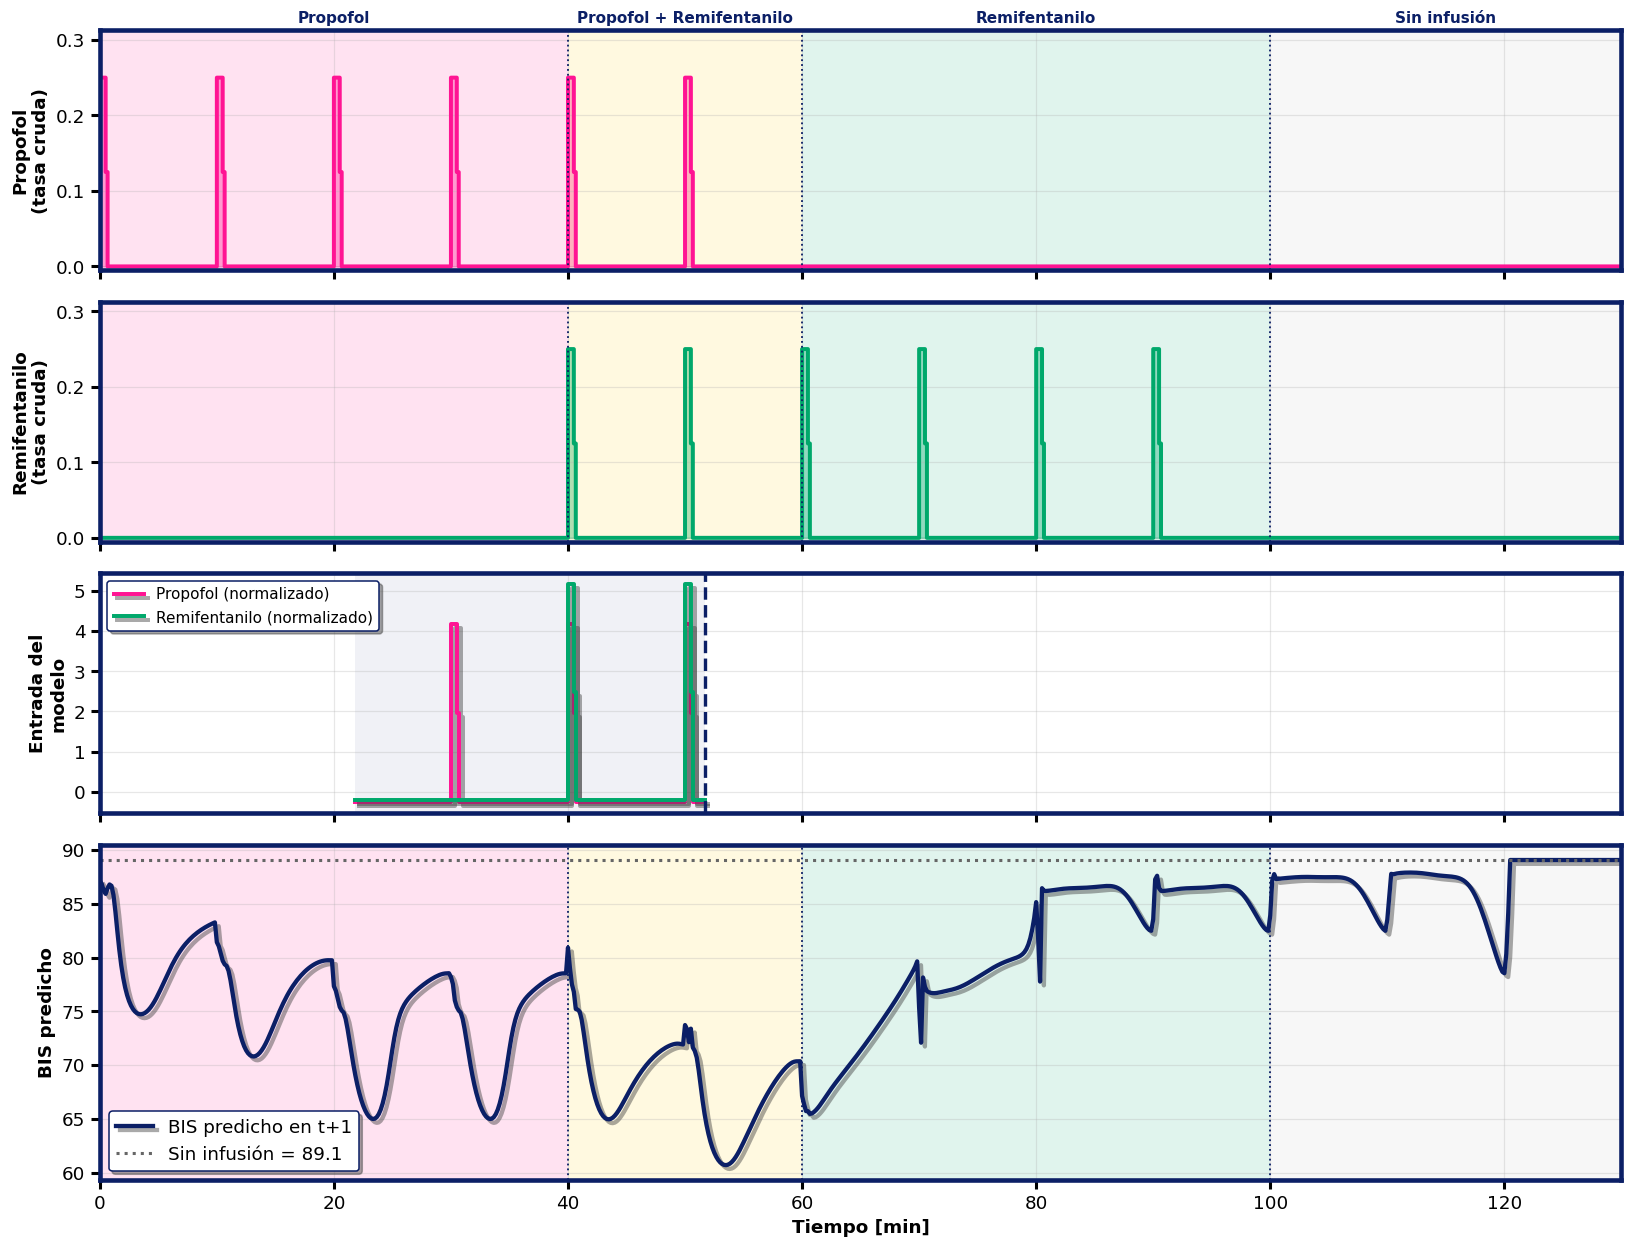

In [11]:
k_ejemplo = min(todos_pulsos[len(todos_pulsos) // 2][1] + 6, N_PASOS - 1)
v_ejemplo = ventanas_protocolo[k_ejemplo].numpy()                  # (2, T)
t_ventana = tiempo_min[k_ejemplo] + (np.arange(T) - (T - 1)) * A_MIN

fig, ejes = plt.subplots(4, 1, figsize=(15, 11.5), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1, 1, 1.4]})
for ax, c in zip(ejes[:2], (0, 1)):
    color = COLOR_FASE[FARMACOS[c]]
    ax.fill_between(tiempo_min, infusion[c], step="post", color=color, alpha=0.35)
    ax.step(tiempo_min, infusion[c], where="post", color=color, lw=2.6)
    ax.set_ylabel(f"{FARMACOS[c]}\n(tasa cruda)")
    ax.set_ylim(-0.02 * infusion.max(), infusion.max() * 1.25 + 1e-6)
sombrear_fases(ejes[0], etiquetas=True)
sombrear_fases(ejes[1])

ax = ejes[2]
for c in (0, 1):
    ax.step(t_ventana, v_ejemplo[c], where="post", color=COLOR_FASE[FARMACOS[c]], lw=2.6,
            label=f"{FARMACOS[c]} (normalizado)", path_effects=RELIEVE)
ax.axvspan(t_ventana[0], t_ventana[-1], color=AZUL_MARINO, alpha=0.06, lw=0)
ax.axvline(tiempo_min[k_ejemplo], color=AZUL_MARINO, lw=2.2, ls="--")
ax.set_ylabel("Entrada del\nmodelo")
leyenda(ax, loc="upper left", fontsize=10)

ejes[3].plot(tiempo_min, bis_pred, color=AZUL_MARINO, lw=2.8, path_effects=RELIEVE,
             label="BIS predicho en t+1")
ejes[3].axhline(bis_base, color="0.4", lw=2, ls=":", label=f"Sin infusión = {bis_base:.1f}")
sombrear_fases(ejes[3])
ejes[3].set_ylabel("BIS predicho"); ejes[3].set_xlabel("Tiempo [min]")
leyenda(ejes[3], loc="best")

for ax in ejes:
    marco_grueso(ax); ax.grid(True, alpha=0.3)
ejes[-1].set_xlim(0, DURACION_TOTAL_MIN)
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "protocolo_y_bis.png"), dpi=300)
plt.show()


## Figura 2. Atención promedio de la última consulta a lo largo de los 130 min

Panel central: $\bar{A}_{T-1,j}$ en función del tiempo $t$ y del retraso de la clave atendida (0 = instante actual; 29.8 min = extremo más antiguo de la ventana). Cada pulso aparece como una banda diagonal que se desplaza hacia retrasos mayores hasta abandonar la ventana. Panel inferior: diferencia respecto de la ventana sin infusión, que elimina el sesgo posicional propio del modelo; el rojo indica instantes que el modelo atiende más por su contenido y el azul, instantes que atiende menos.

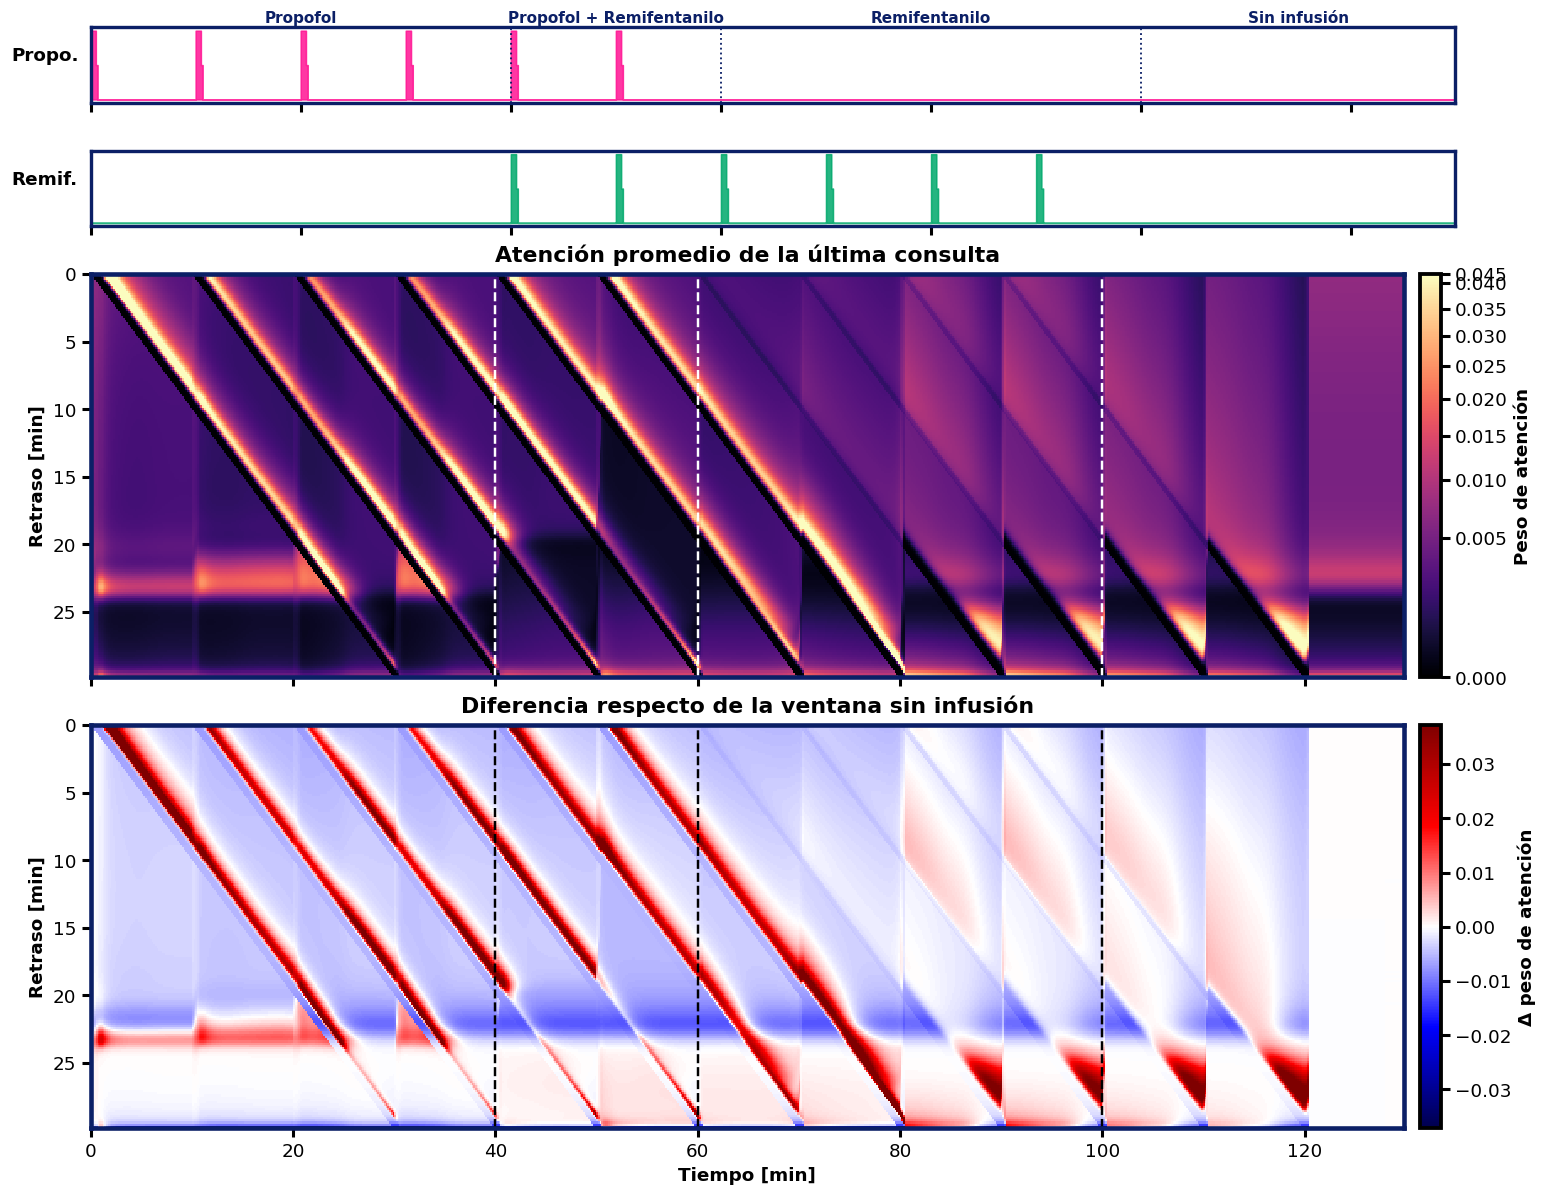

In [12]:
diferencia = mapa_retraso - fila_base[::-1][:, None]
lim = np.percentile(np.abs(diferencia), 99) or 1e-12

fig, ejes = plt.subplots(4, 1, figsize=(16, 13), sharex=True,
                         gridspec_kw={"height_ratios": [0.3, 0.3, 1.6, 1.6]})
for ax, c in zip(ejes[:2], (0, 1)):
    ax.fill_between(tiempo_min, infusion[c], step="post",
                    color=COLOR_FASE[FARMACOS[c]], alpha=0.85)
    ax.set_yticks([]); ax.set_ylabel(FARMACOS[c][:5] + ".", rotation=0, labelpad=30)
    marco_grueso(ax, ancho=2.2)
sombrear_fases(ejes[0], alpha=0.0, etiquetas=True)

extension = [0, tiempo_min[-1], VENTANA_MIN, 0]
im = ejes[2].imshow(mapa_retraso, cmap=MAPA_COLOR, norm=norma_robusta(mapa_retraso),
                    aspect="auto", extent=extension, interpolation="nearest")
ejes[2].set_title("Atención promedio de la última consulta", pad=8)
barra_color(fig, im, ejes[2], fraction=0.025, pad=0.012)

im2 = ejes[3].imshow(diferencia, cmap="seismic", vmin=-lim, vmax=lim, aspect="auto",
                     extent=extension, interpolation="nearest")
ejes[3].set_title("Diferencia respecto de la ventana sin infusión", pad=8)
cb = fig.colorbar(im2, ax=ejes[3], fraction=0.025, pad=0.012)
cb.set_label("Δ peso de atención", fontweight="bold"); cb.outline.set_linewidth(2.5)

for ax in ejes[2:]:
    for a, _, _ in FASES[1:]:
        ax.axvline(a, color="black" if ax is ejes[3] else "white", lw=1.6, ls="--")
    ax.set_ylabel("Retraso [min]")
    marco_grueso(ax)
ejes[-1].set_xlabel("Tiempo [min]")
plt.savefig(os.path.join(CARPETA_FIGURAS, "atencion_deslizante.png"), dpi=300,
            bbox_inches="tight")
plt.show()


## Figura: entradas de pulsos y mapa de la atención promedio

Versión de la Figura 2 destinada al documento. Contiene únicamente las dos entradas de pulsos y el mapa de la atención promedio de la última consulta. Todos los paneles comparten el mismo eje temporal, dado que la barra de color ocupa una columna independiente, de modo que cada pulso queda alineado con la banda diagonal que genera en el mapa. 

Figura exportada en: C:\Users\yordi\Documents\Proyectos_Latex\Tesis\figuras\atencion_promedio_mapa.pdf


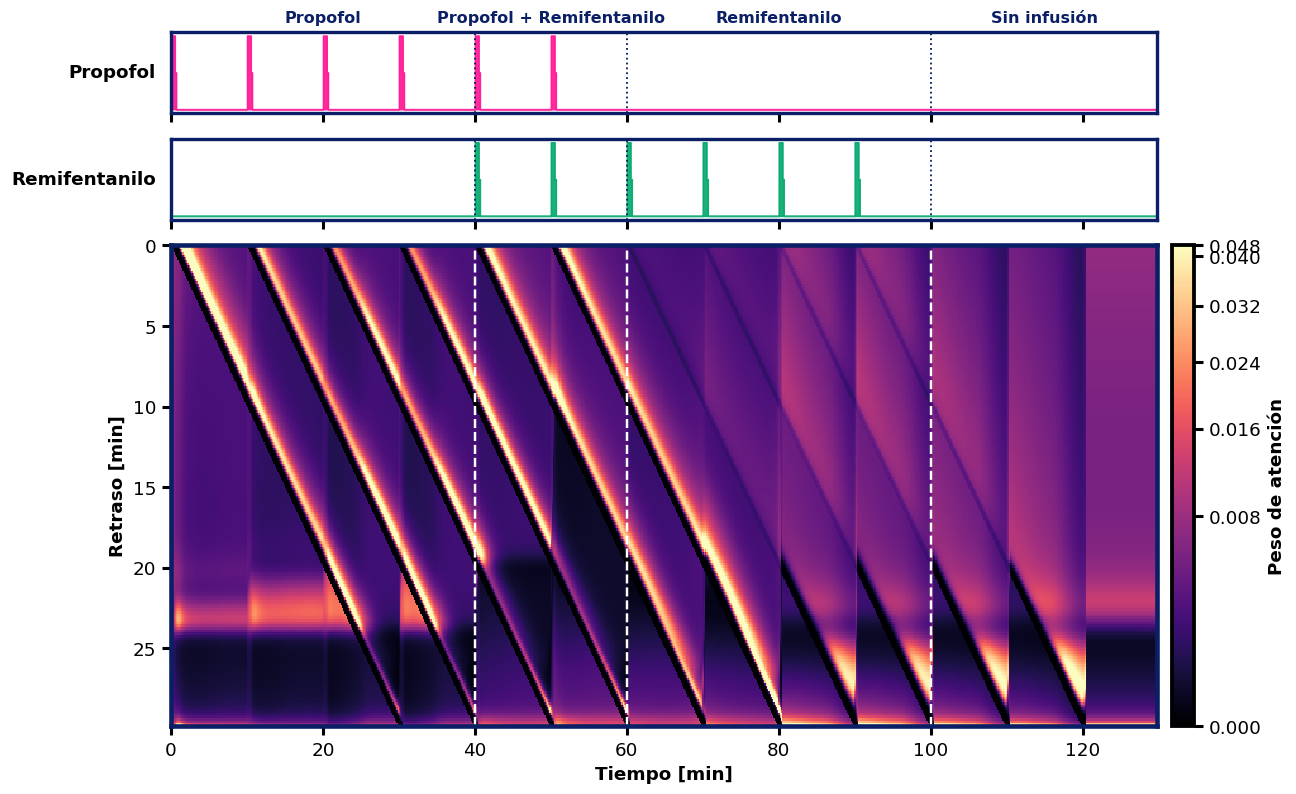

In [13]:
# =============================================================================
# FIGURA PARA LA TESIS: ENTRADAS DE PULSOS Y MAPA DE LA ATENCIÓN PROMEDIO
# =============================================================================
from matplotlib.ticker import MaxNLocator

RUTA_FIGURA_TESIS_MAPA = (r"C:\Users\yordi\Documents\Proyectos_Latex\Tesis"
                          r"\figuras\atencion_promedio_mapa.pdf")

fig = plt.figure(figsize=(12, 8.2))
# Rejilla de tres filas y dos columnas: la segunda columna aloja la barra de
# color, por lo que los tres paneles de datos conservan el mismo ancho
rejilla = fig.add_gridspec(3, 2, height_ratios=[0.32, 0.32, 1.9],
                           width_ratios=[1, 0.022], hspace=0.12, wspace=0.03)
ax_p = fig.add_subplot(rejilla[0, 0])
ax_r = fig.add_subplot(rejilla[1, 0], sharex=ax_p)
ax_m = fig.add_subplot(rejilla[2, 0], sharex=ax_p)
ax_c = fig.add_subplot(rejilla[2, 1])

# ── Entradas de pulsos de propofol y de remifentanilo ─────────────────────────
for ax, c in ((ax_p, 0), (ax_r, 1)):
    ax.fill_between(tiempo_min, infusion[c], step="post",
                    color=COLOR_FASE[FARMACOS[c]], alpha=0.9)
    ax.set_yticks([])
    ax.set_ylabel(FARMACOS[c], rotation=0, ha="right", va="center", labelpad=10)
    ax.tick_params(labelbottom=False)
    for a, _, _ in FASES[1:]:
        ax.axvline(a, color=AZUL_MARINO, lw=1.2, ls=":")
    marco_grueso(ax, ancho=2.2)

# Rótulos de las fases del protocolo sobre el primer panel
for a, b, etiqueta in FASES:
    ax_p.text((a + b) / 2, 1.08, etiqueta, transform=ax_p.get_xaxis_transform(),
              ha="center", va="bottom", fontsize=10.5, fontweight="bold",
              color=AZUL_MARINO)

# ── Mapa de la atención promedio de la última consulta ────────────────────────
extension = [0, tiempo_min[-1], VENTANA_MIN, 0]
im = ax_m.imshow(mapa_retraso, cmap=MAPA_COLOR, norm=norma_robusta(mapa_retraso),
                 aspect="auto", extent=extension, interpolation="nearest")
for a, _, _ in FASES[1:]:
    ax_m.axvline(a, color="white", lw=1.6, ls="--")
ax_m.set_xlim(0, tiempo_min[-1])
ax_m.set_xlabel("Tiempo [min]")
ax_m.set_ylabel("Retraso [min]")
marco_grueso(ax_m)

# Barra de color con un número reducido de marcas para evitar su traslape
cb = fig.colorbar(im, cax=ax_c)
cb.set_label("Peso de atención", fontweight="bold")
cb.outline.set_linewidth(2.5)
cb.locator = MaxNLocator(nbins=6)
cb.update_ticks()

fig.savefig(RUTA_FIGURA_TESIS_MAPA, bbox_inches="tight")
print(f"Figura exportada en: {RUTA_FIGURA_TESIS_MAPA}")
plt.show()


## Figura 3. Horizonte temporal de la atención

Se muestra cuánto del pasado considera el modelo al estimar el BIS: el retraso medio de la atención y el retraso dentro del cual se concentra el 50 % de ella, comparados con los valores de la ventana sin infusión. Un descenso indica que el modelo concentra su atención en el pasado reciente (por ejemplo, en un bolo recién administrado); un aumento indica que recurre a información más antigua. El panel superior reproduce $\Delta\mathrm{BIS}$ como referencia clínica.

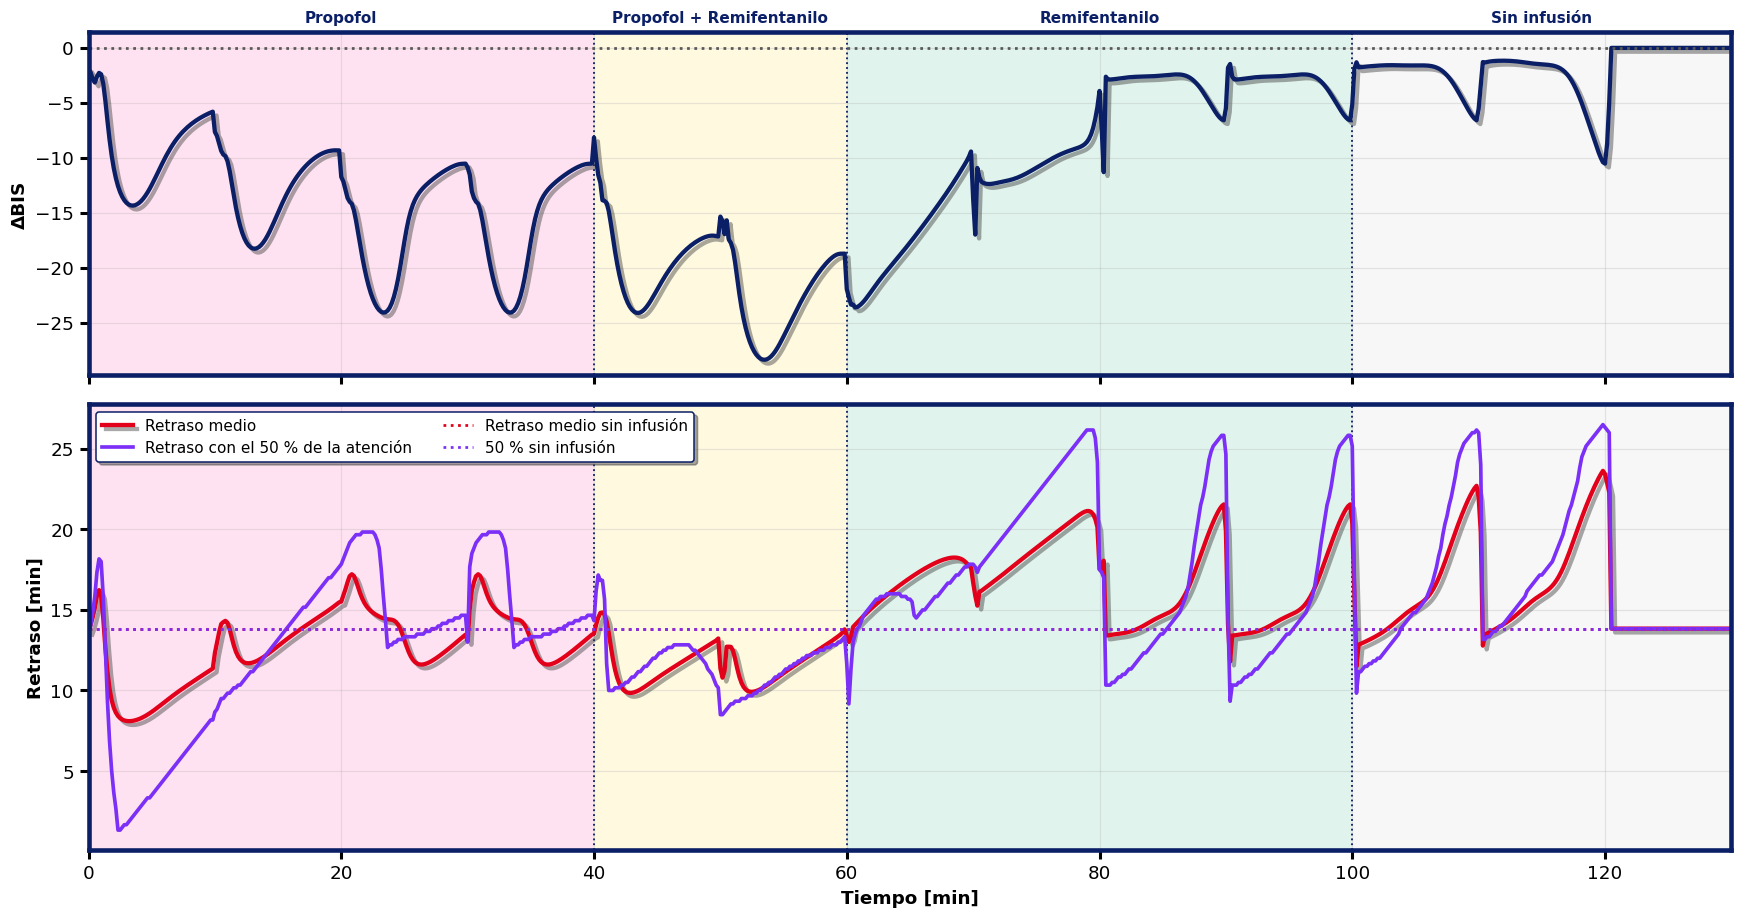

In [14]:
fig, ejes = plt.subplots(2, 1, figsize=(16, 8.5), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1.3]})
ax = ejes[0]
sombrear_fases(ax, etiquetas=True)
ax.plot(tiempo_min, delta_bis, color=AZUL_MARINO, lw=2.8, path_effects=RELIEVE)
ax.axhline(0, color="0.35", lw=1.8, ls=":")
ax.set_ylabel("ΔBIS")

ax = ejes[1]
sombrear_fases(ax)
ax.plot(tiempo_min, ret_medio, color=ROJO, lw=2.8, path_effects=RELIEVE, label="Retraso medio")
ax.plot(tiempo_min, ret_mediano, color="#7B2FF7", lw=2.4, label="Retraso con el 50 % de la atención")
ax.axhline(ret_medio_0, color=ROJO, lw=1.8, ls=":", label="Retraso medio sin infusión")
ax.axhline(ret_mediano_0, color="#7B2FF7", lw=1.8, ls=":", label="50 % sin infusión")
ax.set_ylabel("Retraso [min]"); ax.set_xlabel("Tiempo [min]")
leyenda(ax, fontsize=10, ncol=2, loc="best")

for ax in ejes:
    marco_grueso(ax); ax.grid(True, alpha=0.3)
ejes[-1].set_xlim(0, DURACION_TOTAL_MIN)
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "horizonte_atencion.png"), dpi=300)
plt.show()


## Figura 4. Atención dirigida a los bolos y respuesta del BIS

Para cada fármaco se calcula, en cada instante, la atención relativa (respecto de la ventana sin infusión) asignada a los instantes en que se infundieron sus bolos y a los `VENTANA_POST_BOLO_MIN` minutos posteriores a cada bolo. Los cocientes solo se grafican cuando el intervalo correspondiente ocupa una fracción suficiente de la ventana. En el intervalo traslapado los bolos de ambos fármacos coinciden, por lo que sus curvas no pueden distinguirse entre sí.

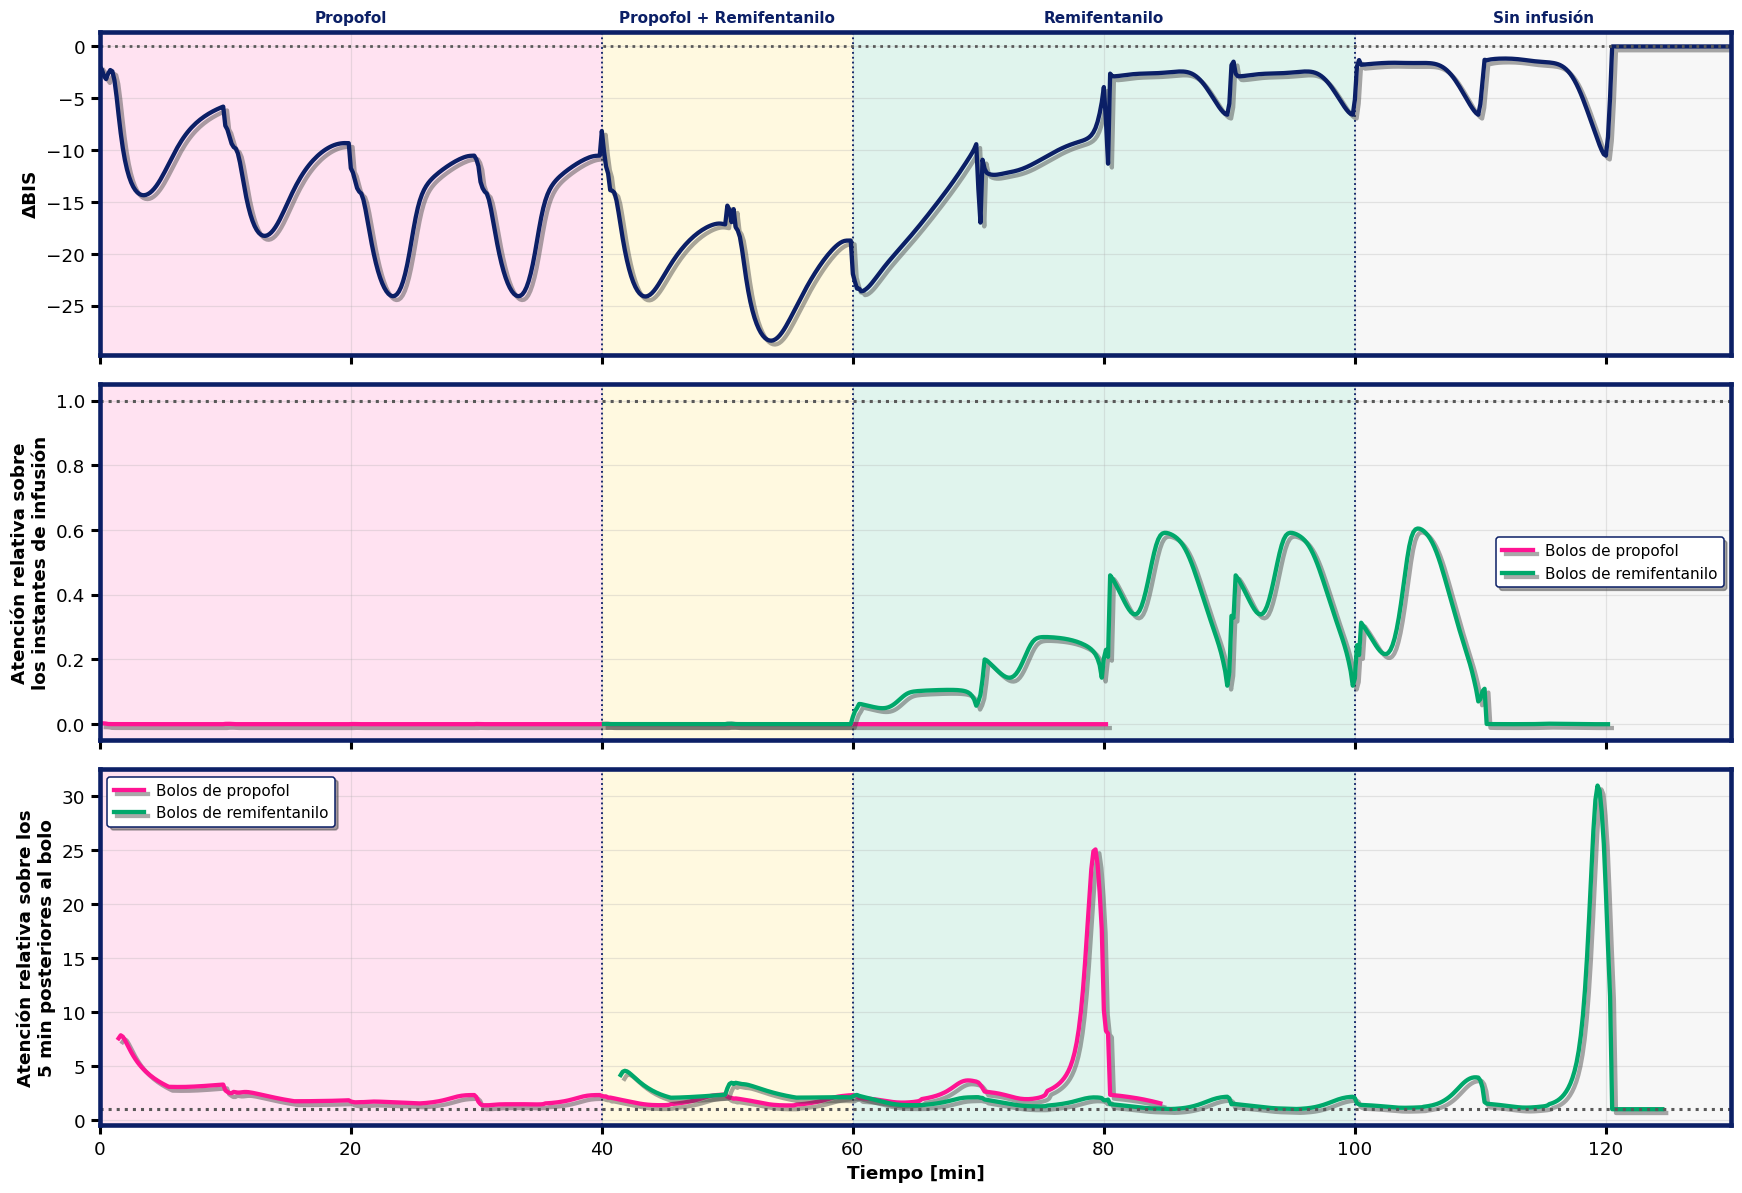

In [15]:
fig, ejes = plt.subplots(3, 1, figsize=(16, 11), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1.1, 1.1]})
ax = ejes[0]
sombrear_fases(ax, etiquetas=True)
ax.plot(tiempo_min, delta_bis, color=AZUL_MARINO, lw=2.8, path_effects=RELIEVE)
ax.axhline(0, color="0.35", lw=1.8, ls=":")
ax.set_ylabel("ΔBIS")

for ax, clave, titulo in [(ejes[1], "bolo", "Atención relativa sobre\nlos instantes de infusión"),
                          (ejes[2], "post", f"Atención relativa sobre los\n{VENTANA_POST_BOLO_MIN} min posteriores al bolo")]:
    sombrear_fases(ax)
    for c, m in masas_farmaco.items():
        minimo = MIN_FRAC_BOLO if clave == "bolo" else MIN_FRAC_POST
        serie = cociente(m[clave], m[clave + "_0"], m["frac_" + clave], minimo)
        ax.plot(tiempo_min, serie, color=COLOR_FASE[FARMACOS[c]], lw=2.8,
                label=f"Bolos de {FARMACOS[c].lower()}", path_effects=RELIEVE)
    ax.axhline(1.0, color="0.35", lw=2, ls=":")
    ax.set_ylabel(titulo)
    leyenda(ax, fontsize=10, loc="best")
ejes[-1].set_xlabel("Tiempo [min]")

for ax in ejes:
    marco_grueso(ax); ax.grid(True, alpha=0.3)
ejes[-1].set_xlim(0, DURACION_TOTAL_MIN)
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "atencion_bolos_y_bis.png"), dpi=300)
plt.show()


## Figura 5. Perfil promedio tras cada tipo de bolo

Los bolos se agrupan según los fármacos activos en su inicio y se alinean respecto de dicho inicio. Para cada grupo se promedian $\Delta\mathrm{BIS}$, la atención relativa sobre el bolo y la atención relativa sobre el periodo posterior al bolo, desde el inicio del bolo hasta que este abandona la ventana (30 min). Las líneas punteadas verticales señalan la llegada de los bolos siguientes del mismo tren.

La tabla final resume, dentro del intervalo entre bolos (primeros `PERIODO_PULSOS_MIN` minutos), la caída máxima del BIS, el tiempo en que ocurre, la atención relativa media sobre el bolo y sobre el periodo posterior, el instante de máxima atención adicional al periodo posterior y el cambio del retraso medio de la atención.

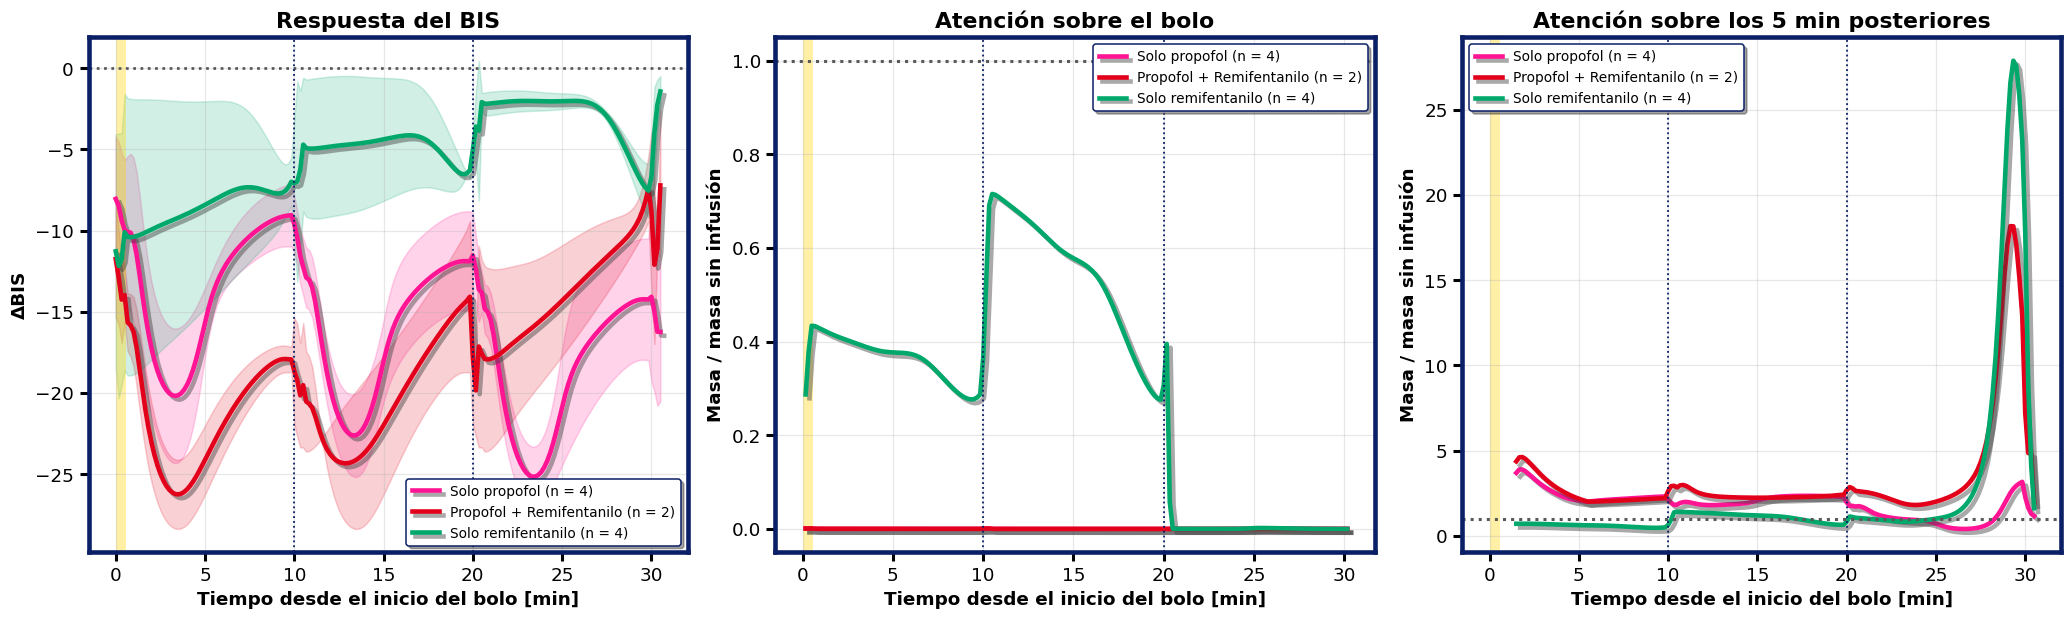

Grupo                         n | ΔBIS mín | t mín [min] | Atención bolo | Atención post | t máx post [min] | Δ retraso medio [min]
-----------------------------------------------------------------------------------------------------------------------------------
Solo propofol                 4 |    -20.2 |         3.3 |         0.000 |         2.317 |              9.8 |                 -1.07
Propofol + Remifentanilo      2 |    -26.2 |         3.5 |         0.000 |         2.398 |              3.0 |                 -2.18
Solo remifentanilo            4 |    -12.2 |         0.2 |         0.367 |         0.597 |              0.7 |                  2.90


In [16]:
largo = T + P_DUR
t_desde = np.arange(largo) * A_MIN
paso_entre = int(PERIODO_PULSOS_MIN * 60 / PERIODO_MUESTREO)
base_rep = np.broadcast_to(fila_base, filas_promedio.shape)

perfiles, tabla = {}, []
for etiqueta, lista in grupos_pulsos.items():
    validos = [(p0, p1) for p0, p1 in lista if p0 + largo <= N_PASOS]
    if not validos:
        print(f"[AVISO] {etiqueta}: ningún bolo completa su recorrido; se omite")
        continue
    seg = lambda serie: np.stack([serie[p0:p0 + largo] for p0, _ in validos])
    d_bis  = seg(delta_bis)
    bolo   = np.stack([masa_intervalo(filas_promedio, p0, p1)[p0:p0 + largo] for p0, p1 in validos])
    bolo_0 = np.stack([masa_intervalo(base_rep,       p0, p1)[p0:p0 + largo] for p0, p1 in validos])
    post   = np.stack([masa_intervalo(filas_promedio, p1, p1 + P_POST)[p0:p0 + largo] for p0, p1 in validos])
    post_0 = np.stack([masa_intervalo(base_rep,       p1, p1 + P_POST)[p0:p0 + largo] for p0, p1 in validos])
    # Fracción de la ventana ocupada por el bolo y por su periodo posterior; depende
    # solo del tiempo transcurrido desde el inicio, por lo que basta un bolo de referencia
    q0, q1 = validos[0]
    frac_bolo = fraccion_uniforme(N_PASOS, q0, q1)[q0:q0 + largo]
    frac_post = fraccion_uniforme(N_PASOS, q1, q1 + P_POST)[q0:q0 + largo]
    perfiles[etiqueta] = dict(
        n=len(validos), d_bis=d_bis.mean(0), d_bis_std=d_bis.std(0),
        rel_bolo=cociente(bolo.mean(0), bolo_0.mean(0), frac_bolo, MIN_FRAC_BOLO),
        rel_post=cociente(post.mean(0), post_0.mean(0), frac_post, MIN_FRAC_POST),
        ret=np.stack([ret_medio[p0:p0 + largo] for p0, _ in validos]).mean(0))

    # Resumen dentro del intervalo entre bolos
    e = slice(0, min(paso_entre, largo))
    e_post = slice(P_DUR, min(paso_entre, largo))
    exceso_post = (post.mean(0) - post_0.mean(0))[e_post]
    tabla.append((etiqueta, len(validos),
                  perfiles[etiqueta]["d_bis"][e].min(),
                  t_desde[e][np.argmin(perfiles[etiqueta]["d_bis"][e])],
                  bolo.mean(0)[e].sum() / max(bolo_0.mean(0)[e].sum(), 1e-12),
                  post.mean(0)[e_post].sum() / max(post_0.mean(0)[e_post].sum(), 1e-12),
                  t_desde[e_post][np.argmax(exceso_post)],
                  perfiles[etiqueta]["ret"][e].mean() - ret_medio_0))

fig, ejes = plt.subplots(1, 3, figsize=(19, 5.8))
for etiqueta, p in perfiles.items():
    color = COLOR_GRUPO.get(etiqueta, AZUL_MARINO)
    etiq = f"{etiqueta} (n = {p['n']})"
    ejes[0].fill_between(t_desde, p["d_bis"] - p["d_bis_std"], p["d_bis"] + p["d_bis_std"],
                         color=color, alpha=0.18)
    ejes[0].plot(t_desde, p["d_bis"], color=color, lw=3, label=etiq, path_effects=RELIEVE)
    ejes[1].plot(t_desde, p["rel_bolo"], color=color, lw=3, label=etiq, path_effects=RELIEVE)
    ejes[2].plot(t_desde, p["rel_post"], color=color, lw=3, label=etiq, path_effects=RELIEVE)
ejes[0].axhline(0, color="0.35", lw=1.8, ls=":")
for ax in ejes[1:]:
    ax.axhline(1.0, color="0.35", lw=2, ls=":")
ejes[0].set_ylabel("ΔBIS"); ejes[0].set_title("Respuesta del BIS")
ejes[1].set_ylabel("Masa / masa sin infusión"); ejes[1].set_title("Atención sobre el bolo")
ejes[2].set_ylabel("Masa / masa sin infusión")
ejes[2].set_title(f"Atención sobre los {VENTANA_POST_BOLO_MIN} min posteriores")
for ax in ejes:
    ax.axvspan(0, DURACION_PULSO_S / 60, color=AMARILLO, alpha=0.35, lw=0)
    for m in range(1, int(VENTANA_MIN // PERIODO_PULSOS_MIN) + 1):
        ax.axvline(m * PERIODO_PULSOS_MIN, color=AZUL_MARINO, lw=1.2, ls=":")
    ax.set_xlabel("Tiempo desde el inicio del bolo [min]")
    leyenda(ax, fontsize=9, loc="best"); marco_grueso(ax); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "perfil_por_tipo_de_bolo.png"), dpi=300)
plt.show()

encabezado = (f"{'Grupo':<28s} {'n':>2s} | {'ΔBIS mín':>8s} | {'t mín [min]':>11s} | "
              f"{'Atención bolo':>13s} | {'Atención post':>13s} | {'t máx post [min]':>16s} | "
              f"{'Δ retraso medio [min]':>21s}")
print(encabezado + "\n" + "-" * len(encabezado))
for fila in tabla:
    print(f"{fila[0]:<28s} {fila[1]:>2d} | {fila[2]:>8.1f} | {fila[3]:>11.1f} | {fila[4]:>13.3f} | "
          f"{fila[5]:>13.3f} | {fila[6]:>16.1f} | {fila[7]:>21.2f}")


## Figura 6. Mapa completo $\bar{A}$ en una ventana representativa de cada fase

Para cada grupo de bolos se toma el primero del grupo y se muestra la matriz $\bar{A}$ completa de la ventana que finaliza `RETRASO_VENTANA_DETALLE_MIN` minutos después de su fin; como referencia se incluye una ventana en la que ya no permanece ningún bolo. Las líneas punteadas delimitan cada bolo contenido en la ventana; la fila inferior de cada mapa corresponde a la última consulta.

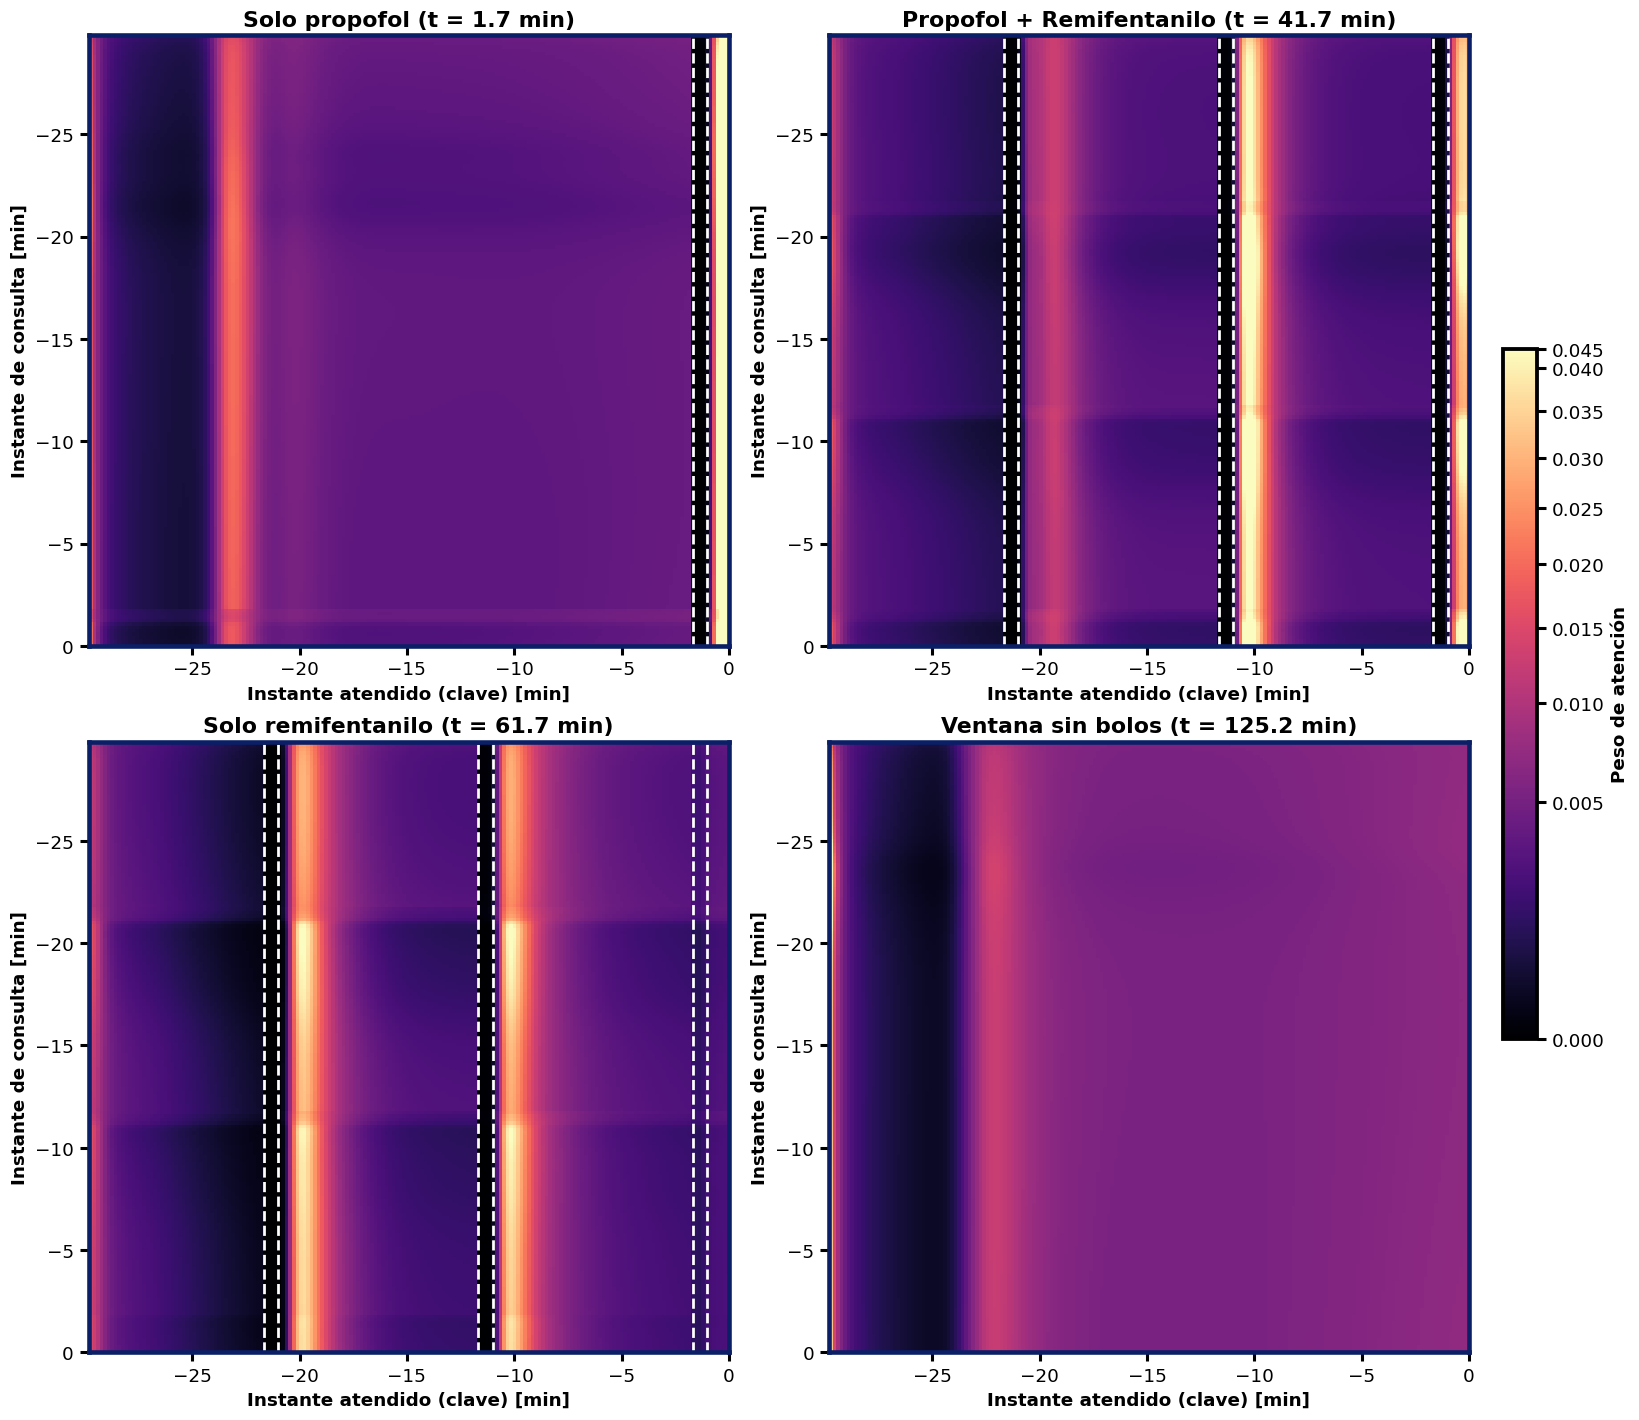

In [17]:
extension_v = [-VENTANA_MIN, 0, 0, -VENTANA_MIN]       # 0 = instante actual

casos = []
for etiqueta, lista in grupos_pulsos.items():
    p0, p1 = lista[0]
    k = min(p1 + int(RETRASO_VENTANA_DETALLE_MIN * 60 / PERIODO_MUESTREO), N_PASOS - 1)
    casos.append((etiqueta, k))
k_libre = max(p1 for _, p1 in todos_pulsos) + T
if k_libre < N_PASOS:
    casos.append(("Ventana sin bolos", (k_libre + N_PASOS - 1) // 2))

mapas = []
for etiqueta, k in casos:
    r = extraer_atencion(modelo, ventanas_protocolo[k:k + 1].to(dispositivo), bis_hist_0, covariables)
    mapas.append(r["promedio"][0].cpu().numpy())
norma = norma_robusta(np.stack(mapas))

columnas = min(2, len(casos))
filas_f = int(np.ceil(len(casos) / columnas))
fig, ejes = plt.subplots(filas_f, columnas, figsize=(7.4 * columnas, 6.4 * filas_f),
                         constrained_layout=True)
ejes = np.atleast_1d(ejes).ravel()
for ax, (etiqueta, k), A in zip(ejes, casos, mapas):
    im = ax.imshow(A, cmap=MAPA_COLOR, norm=norma, extent=extension_v, aspect="auto",
                   interpolation="nearest")
    for p0, p1 in todos_pulsos:
        a_rel, b_rel = (p0 - k) * A_MIN, (p1 - k) * A_MIN
        if b_rel > -VENTANA_MIN and a_rel <= 0:
            for x in (a_rel, b_rel):
                ax.axvline(x, color="white", lw=1.8, ls="--")
    ax.set_title(f"{etiqueta} (t = {tiempo_min[k]:.1f} min)")
    ax.set_xlabel("Instante atendido (clave) [min]")
    ax.set_ylabel("Instante de consulta [min]")
    marco_grueso(ax)
for ax in ejes[len(casos):]:
    ax.axis("off")
barra_color(fig, im, ejes.tolist(), fraction=0.025, pad=0.02)
plt.savefig(os.path.join(CARPETA_FIGURAS, "mapas_completos_por_fase.png"), dpi=300,
            bbox_inches="tight")
plt.show()


## Análisis de robustez ante el contexto del paciente

Los resultados anteriores corresponden a un único contexto de paciente. En esta sección se repite el protocolo con varios contextos del conjunto de prueba, correspondientes a pacientes distintos y con historial completo. Una conclusión se considera robusta cuando se verifica en todos los contextos evaluados. Los pacientes se eligen de manera equiespaciada a lo largo del conjunto de prueba, excluyendo al del análisis principal; alternativamente, los índices pueden fijarse en `INDICES_CONTEXTO`. Por simplicidad, en esta sección el historial de BIS se mantiene fijo para cada contexto.

**Métricas por contexto y por grupo de bolos:**
* **Caída máxima del BIS:** mínimo de $\Delta\mathrm{BIS}$ en los 8 min posteriores al último bolo del grupo; en ese instante la ventana contiene el máximo número de bolos del mismo régimen (tres), lo que hace comparables los grupos.
* **Atención relativa sobre el bolo** y **sobre el periodo posterior al bolo**, acumuladas a lo largo de la permanencia de los bolos del grupo en la ventana.

In [18]:
# =============================================================================
# CONFIGURACIÓN DEL ANÁLISIS DE ROBUSTEZ
# =============================================================================
N_CONTEXTOS        = 5          # Número de pacientes distintos a evaluar
INDICES_CONTEXTO   = None       # Lista de índices del conjunto de prueba; None = selección automática
VENTANA_NADIR_MIN  = 8          # Minutos posteriores al bolo en que se busca la caída máxima
TOLERANCIA_BIS     = 1.0        # Diferencia mínima de BIS para considerar distintas dos respuestas


In [19]:
# =============================================================================
# SELECCIÓN DE CONTEXTOS Y RECORRIDO
# =============================================================================
if INDICES_CONTEXTO is not None:
    indices = list(INDICES_CONTEXTO)
else:
    candidatos = [i for p, (a, b) in enumerate(zip(inicios_pac, finales_pac)) if p != paciente_ref
                  for i in [indice_representativo(a, b)] if i is not None]
    if not candidatos:
        raise RuntimeError("No se encontraron ventanas válidas en el conjunto de prueba")
    posiciones = np.unique(np.linspace(0, len(candidatos) - 1,
                                       min(N_CONTEXTOS, len(candidatos))).round().astype(int))
    indices = [candidatos[p] for p in posiciones]

contextos = [{"etiqueta": f"Principal (muestra {INDICE_MUESTRA})", "indice": INDICE_MUESTRA}]
contextos += [{"etiqueta": f"Contexto {n} (muestra {idx})", "indice": idx}
              for n, idx in enumerate(indices, start=1)]

pasos_nadir = int(VENTANA_NADIR_MIN * 60 / PERIODO_MUESTREO)
grupos = list(grupos_pulsos)
t0 = time.time()
for ctx in contextos:
    idx = ctx["indice"]
    cov_c = cov_todas[idx:idx + 1].to(dispositivo)
    bh_c  = bis_n_todas[idx:idx + 1].to(dispositivo)
    filas_c, pred_c = recorrer_fijo(bh_c, cov_c)
    r0 = extraer_atencion(modelo, torch.zeros(1, 2, T, device=dispositivo), bh_c, cov_c,
                          solo_ultima_fila=True)
    ctx["filas"]     = filas_c
    ctx["fila_base"] = r0["promedio"][0].cpu().numpy()
    ctx["bis_pred"]  = pred_c
    ctx["bis_base"]  = r0["bis_pred"].item()
    ctx["delta_bis"] = pred_c - ctx["bis_base"]
    ctx["bis_medio"] = bis_gt_todas[idx].mean().item()
    ctx["nadir"], ctx["rel_bolo"], ctx["rel_post"] = {}, {}, {}
    for etiqueta, lista in grupos_pulsos.items():
        p0_ult = lista[-1][0]
        ctx["nadir"][etiqueta] = float(ctx["delta_bis"][p0_ult:min(p0_ult + pasos_nadir, N_PASOS)].min())
        m = masas_clinicas(filas_c, ctx["fila_base"], lista)
        ctx["rel_bolo"][etiqueta] = float(m["bolo"].sum() / max(m["bolo_0"].sum(), 1e-12))
        ctx["rel_post"][etiqueta] = float(m["post"].sum() / max(m["post_0"].sum(), 1e-12))
print(f"[INFO] {len(contextos)} contextos evaluados en {time.time() - t0:.1f} s\n")

def imprimir_tabla(titulo, clave, formato):
    encabezado = f"{titulo:<32s} | " + " | ".join(f"{g[:24]:>24s}" for g in grupos)
    print(encabezado + "\n" + "-" * len(encabezado))
    for ctx in contextos:
        print(f"{ctx['etiqueta']:<32s} | " + " | ".join(format(ctx[clave][g], formato).rjust(24) for g in grupos))
    print()

print(f"{'Contexto':<32s} | BIS medio del historial | BIS sin infusión")
for ctx in contextos:
    print(f"{ctx['etiqueta']:<32s} | {ctx['bis_medio']:>23.1f} | {ctx['bis_base']:>16.1f}")
print()
imprimir_tabla("Caída máxima de ΔBIS", "nadir", ".1f")
imprimir_tabla("Atención relativa sobre el bolo", "rel_bolo", ".3f")
imprimir_tabla("Atención relativa posterior", "rel_post", ".3f")


[INFO] 6 contextos evaluados en 0.5 s

Contexto                         | BIS medio del historial | BIS sin infusión
Principal (muestra 365)          |                    64.9 |             89.1
Contexto 1 (muestra 1291)        |                    38.7 |             85.8
Contexto 2 (muestra 11013)       |                    29.2 |             88.4
Contexto 3 (muestra 18729)       |                    39.5 |             88.4
Contexto 4 (muestra 27004)       |                    48.1 |             85.0
Contexto 5 (muestra 37908)       |                    39.5 |             86.1

Caída máxima de ΔBIS             |            Solo propofol | Propofol + Remifentanilo |       Solo remifentanilo
-----------------------------------------------------------------------------------------------------------------
Principal (muestra 365)          |                    -24.1 |                    -28.4 |                     -5.5
Contexto 1 (muestra 1291)        |                    -29.5 |           

## Figura 7. BIS predicho con distintos contextos

Panel superior: BIS predicho para cada contexto. Panel inferior: $\Delta\mathrm{BIS}$ respecto de la predicción sin infusión del mismo contexto, lo que permite comparar la forma de la respuesta con independencia del nivel basal de cada paciente.

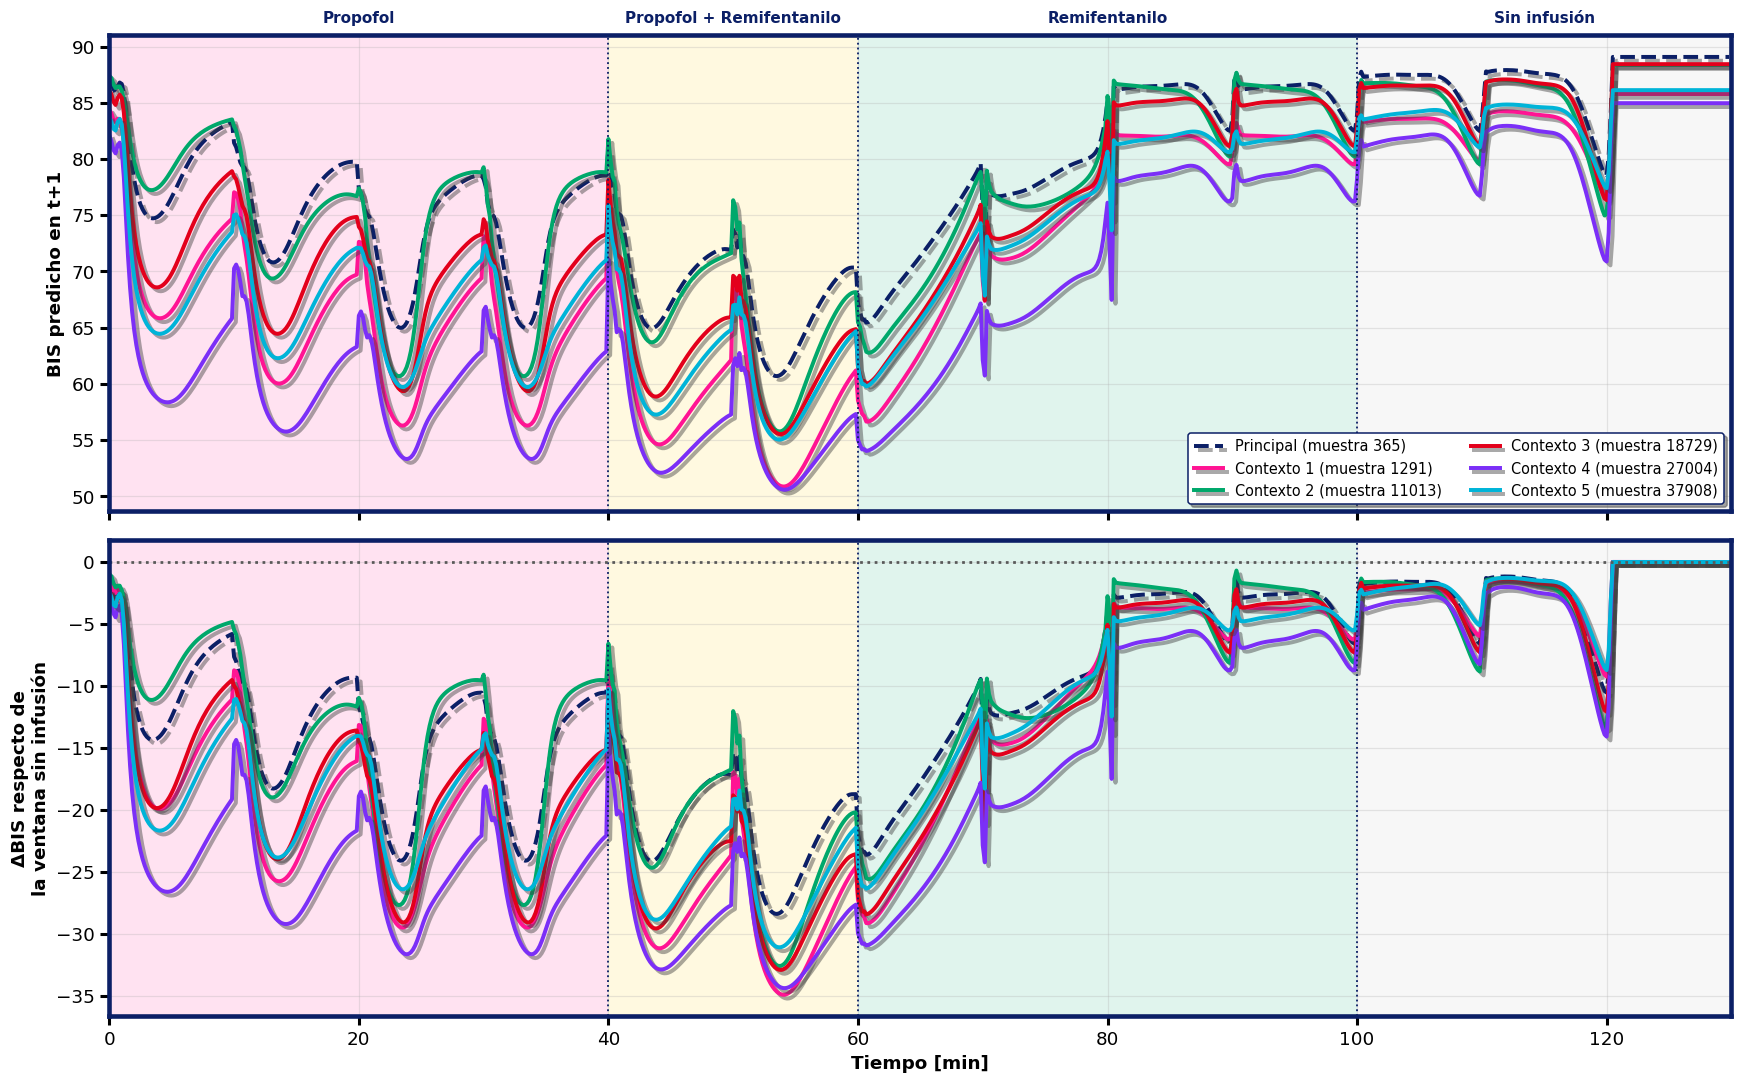

In [20]:
COLORES_CTX = [AZUL_MARINO, ROSA_FLUOR, ESMERALDA, ROJO, "#7B2FF7", "#00B4D8", AMARILLO, "#FF7F11"]

fig, ejes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
for i, ctx in enumerate(contextos):
    color = COLORES_CTX[i % len(COLORES_CTX)]
    estilo = "--" if i == 0 else "-"
    ejes[0].plot(tiempo_min, ctx["bis_pred"], color=color, lw=2.6, ls=estilo,
                 label=ctx["etiqueta"], path_effects=RELIEVE)
    ejes[1].plot(tiempo_min, ctx["delta_bis"], color=color, lw=2.6, ls=estilo,
                 path_effects=RELIEVE)
sombrear_fases(ejes[0], etiquetas=True)
sombrear_fases(ejes[1])
ejes[1].axhline(0, color="0.35", lw=1.8, ls=":")
ejes[0].set_ylabel("BIS predicho en t+1")
ejes[1].set_ylabel("ΔBIS respecto de\nla ventana sin infusión")
ejes[1].set_xlabel("Tiempo [min]")
leyenda(ejes[0], fontsize=9.5, ncol=2, loc="best")
for ax in ejes:
    marco_grueso(ax); ax.grid(True, alpha=0.3)
ejes[-1].set_xlim(0, DURACION_TOTAL_MIN)
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "robustez_bis_contextos.png"), dpi=300)
plt.show()


## Figura 8. Métricas clínicas por régimen y por contexto

Panel izquierdo: caída máxima de $\Delta\mathrm{BIS}$ tras el último bolo de cada grupo (valores más negativos indican mayor efecto hipnótico). Paneles central y derecho: atención relativa sobre el bolo y sobre el periodo posterior al bolo (la línea punteada indica el valor unitario).

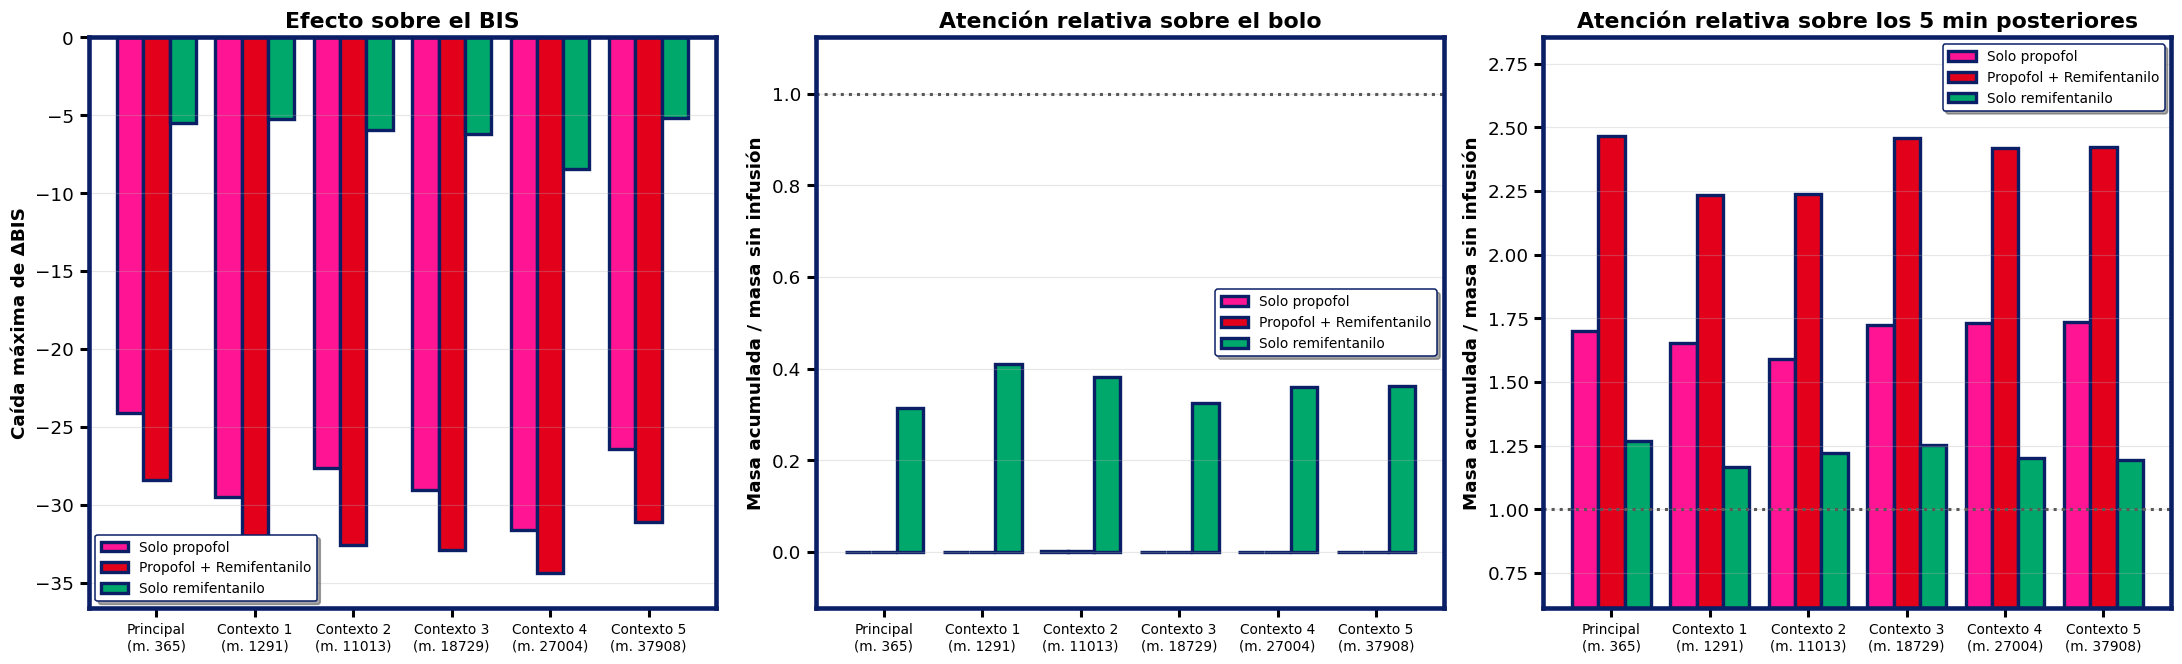

In [21]:
fig, ejes = plt.subplots(1, 3, figsize=(20, 6.2))
x = np.arange(len(contextos))
ancho = 0.8 / len(grupos)
for g, etiqueta in enumerate(grupos):
    desplaz = (g - (len(grupos) - 1) / 2) * ancho
    color = COLOR_GRUPO.get(etiqueta, AZUL_MARINO)
    for ax, clave in zip(ejes, ("nadir", "rel_bolo", "rel_post")):
        ax.bar(x + desplaz, [c[clave][etiqueta] for c in contextos], width=ancho,
               color=color, edgecolor=AZUL_MARINO, linewidth=2.2, label=etiqueta)
ejes[0].axhline(0, color="0.35", lw=1.8)
ejes[0].set_ylabel("Caída máxima de ΔBIS")
ejes[0].set_title("Efecto sobre el BIS")
for ax, titulo in zip(ejes[1:], ("Atención relativa sobre el bolo",
                                 f"Atención relativa sobre los {VENTANA_POST_BOLO_MIN} min posteriores")):
    ax.axhline(1.0, color="0.35", lw=2, ls=":")
    ax.set_ylabel("Masa acumulada / masa sin infusión")
    ax.set_title(titulo)
    # Escala vertical ajustada a los datos para apreciar diferencias alrededor de uno
    valores = [b.get_height() for b in ax.patches]
    margen = max(0.005, (max(valores) - min(valores)) * 0.3)
    ax.set_ylim(min(min(valores), 1.0) - margen, max(max(valores), 1.0) + margen)
etiquetas_x = [c["etiqueta"].replace(" (muestra ", "\n(m. ") for c in contextos]
for ax in ejes:
    ax.set_xticks(x); ax.set_xticklabels(etiquetas_x, fontsize=9)
    leyenda(ax, fontsize=9); marco_grueso(ax); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "robustez_metricas.png"), dpi=300)
plt.show()


## Figura 9. Diferencia de atención respecto de la ventana sin infusión en cada contexto

Si los patrones asociados a los bolos coinciden entre paneles, la interpretación de la atención no depende del paciente.

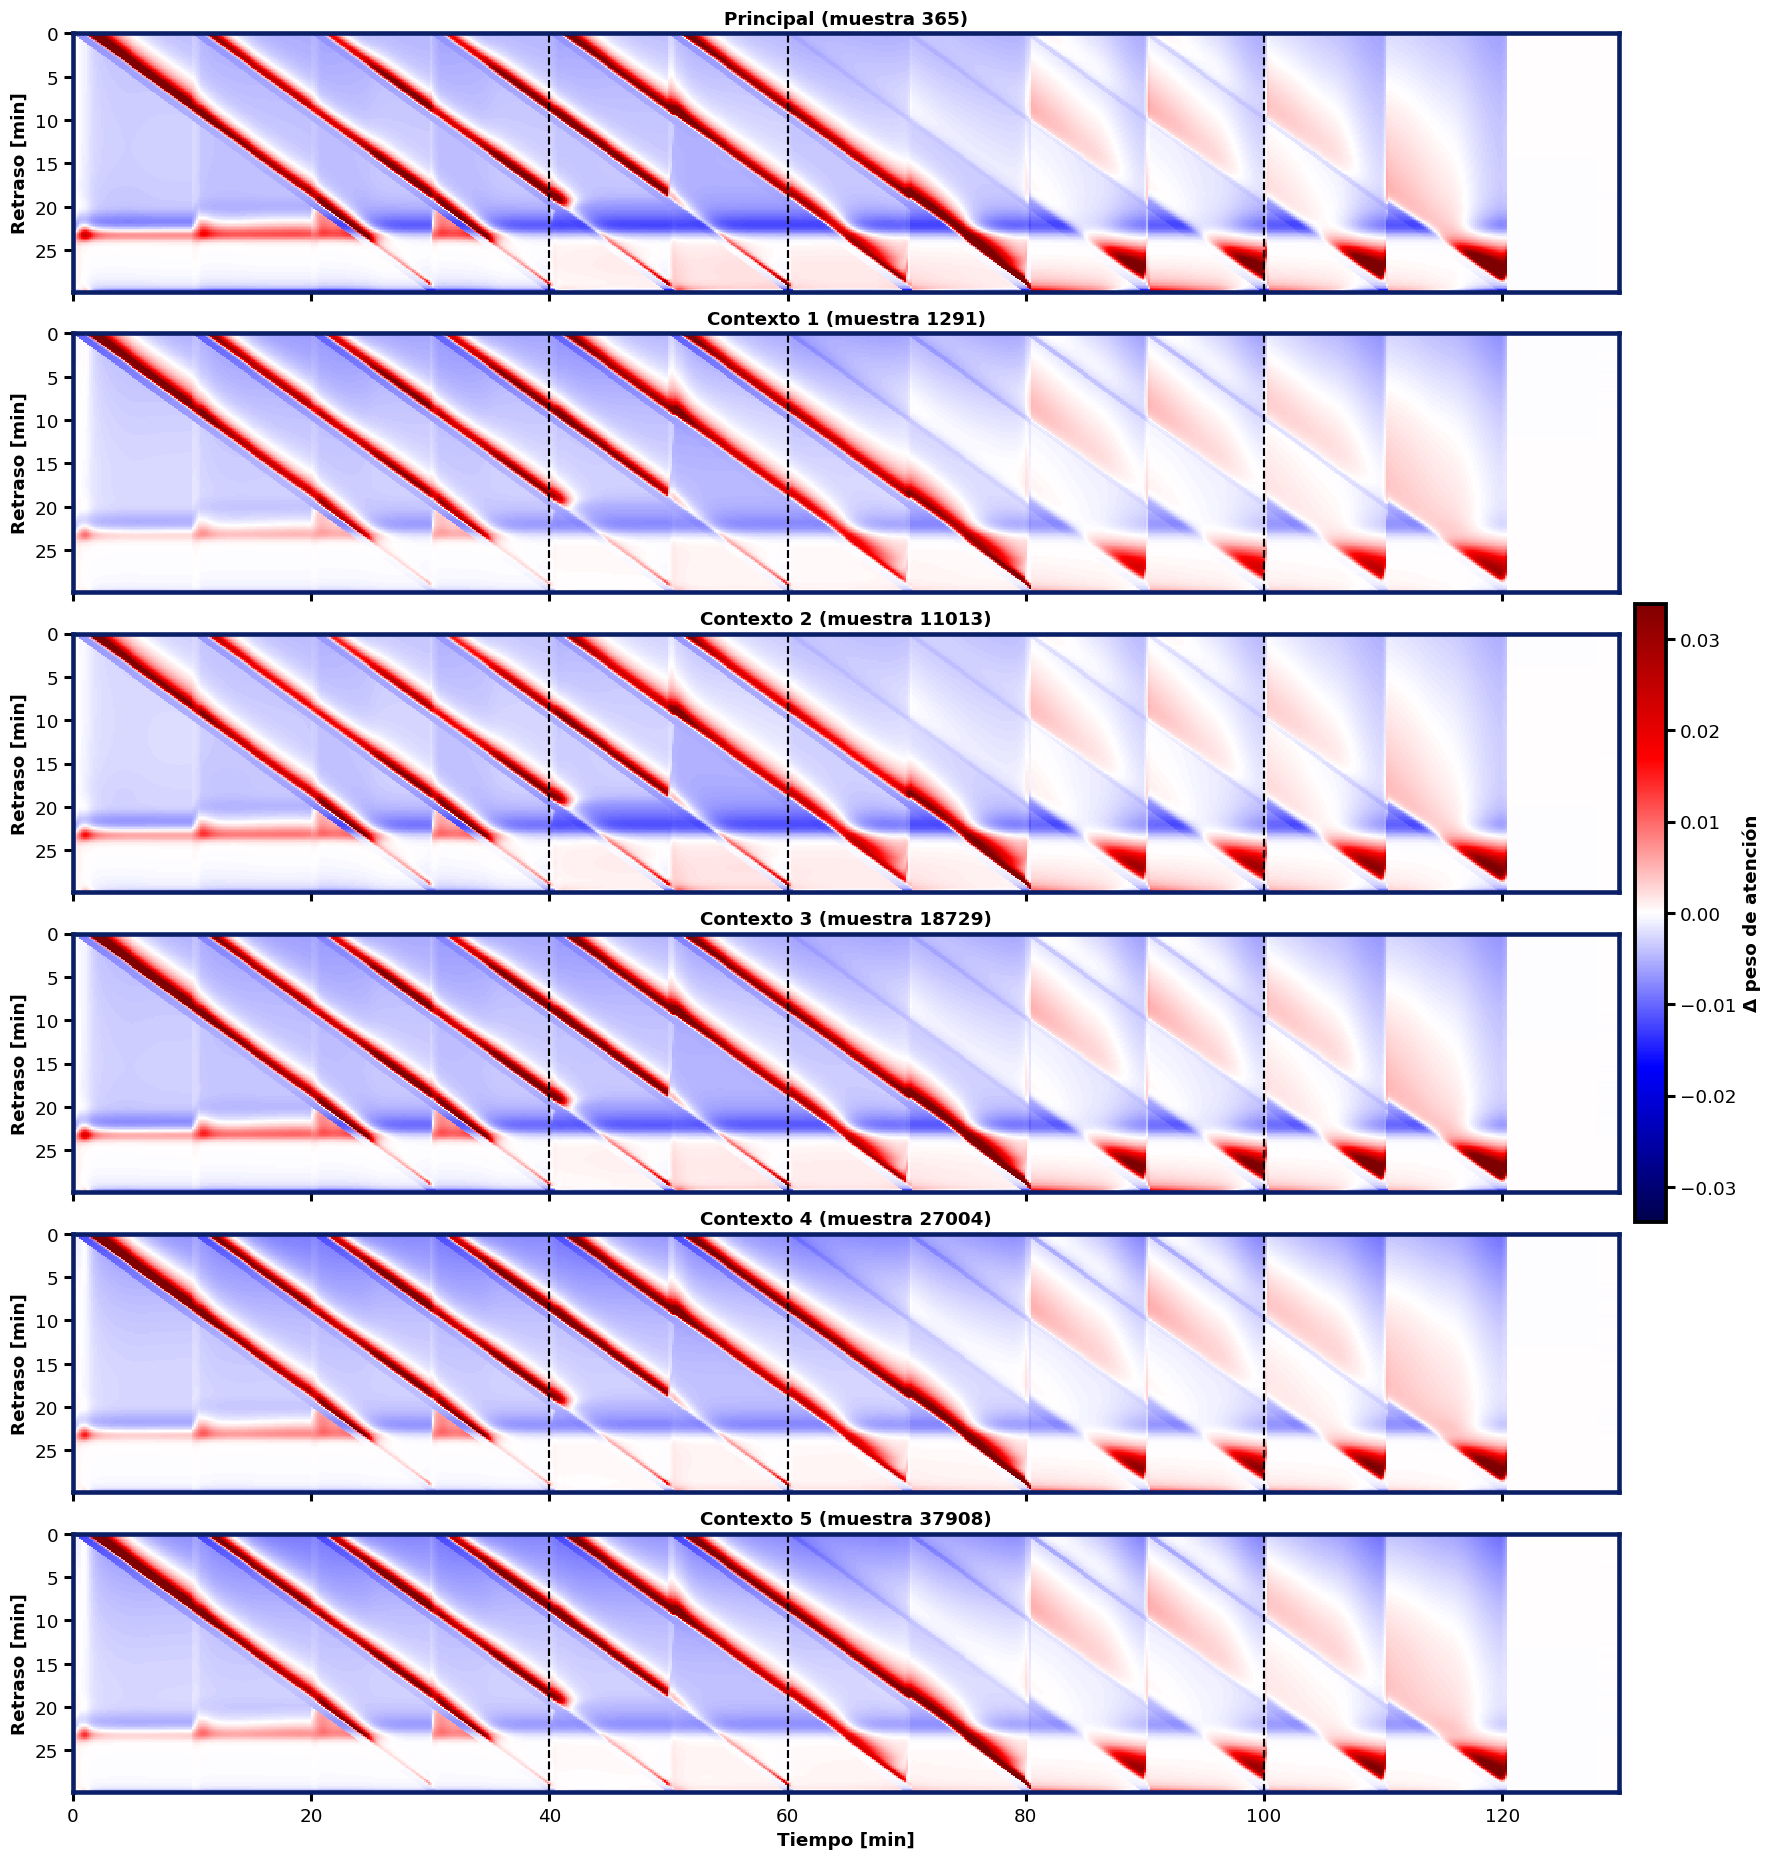

In [22]:
difs = [(c["filas"] - c["fila_base"][None, :])[:, ::-1].T for c in contextos]
lim = np.percentile(np.abs(np.concatenate([d.ravel() for d in difs])), 99) or 1e-12

fig, ejes = plt.subplots(len(contextos), 1, figsize=(16, 2.8 * len(contextos)),
                         sharex=True, constrained_layout=True)
ejes = np.atleast_1d(ejes)
for ax, ctx, d in zip(ejes, contextos, difs):
    im = ax.imshow(d, cmap="seismic", vmin=-lim, vmax=lim, aspect="auto",
                   extent=[0, tiempo_min[-1], VENTANA_MIN, 0], interpolation="nearest")
    for a, _, _ in FASES[1:]:
        ax.axvline(a, color="black", lw=1.4, ls="--")
    ax.set_title(ctx["etiqueta"], fontsize=12)
    ax.set_ylabel("Retraso [min]")
    marco_grueso(ax)
ejes[-1].set_xlabel("Tiempo [min]")
cb = fig.colorbar(im, ax=ejes.tolist(), fraction=0.02, pad=0.01)
cb.set_label("Δ peso de atención", fontweight="bold"); cb.outline.set_linewidth(2.5)
plt.savefig(os.path.join(CARPETA_FIGURAS, "robustez_atencion_contextos.png"), dpi=300,
            bbox_inches="tight")
plt.show()


## Verificación de las conclusiones en todos los contextos

Se evalúan de forma automática las afirmaciones principales del análisis. Para cada una se indica en cuántos contextos se cumple; solo las que se verifican en la totalidad de ellos deben considerarse robustas.

In [23]:
g_p = "Solo propofol" if "Solo propofol" in grupos else None
g_r = "Solo remifentanilo" if "Solo remifentanilo" in grupos else None
g_c = next((g for g in grupos if "+" in g), None)

afirmaciones = []
if g_p and g_r:
    afirmaciones += [
        ("El propofol solo reduce el BIS más que el remifentanilo solo",
         lambda c: c["nadir"][g_p] < c["nadir"][g_r] - TOLERANCIA_BIS),
        (f"El remifentanilo solo reduce el BIS menos de {2 * TOLERANCIA_BIS:.0f} puntos",
         lambda c: c["nadir"][g_r] > -2 * TOLERANCIA_BIS),
    ]
if g_p and g_c:
    afirmaciones.append(("La combinación reduce el BIS más que el propofol solo",
                         lambda c: c["nadir"][g_c] < c["nadir"][g_p] - TOLERANCIA_BIS))
if g_p:
    afirmaciones += [
        ("Los instantes de infusión de propofol reciben menos atención que sin infusión",
         lambda c: c["rel_bolo"][g_p] < 1.0),
        ("El periodo posterior a los bolos de propofol recibe más atención que sin infusión",
         lambda c: c["rel_post"][g_p] > 1.0),
    ]
if g_p and g_r:
    afirmaciones.append(("El periodo posterior al propofol recibe más atención que el posterior al remifentanilo",
                         lambda c: c["rel_post"][g_p] > c["rel_post"][g_r]))

print(f"Contextos considerados: {len(contextos)}\n")
for texto, criterio in afirmaciones:
    cumple = [criterio(c) for c in contextos]
    marca = "ROBUSTA     " if all(cumple) else ("PARCIAL     " if any(cumple) else "NO SE CUMPLE")
    print(f"[{marca}] {texto}: {sum(cumple)}/{len(cumple)}")


Contextos considerados: 6

[ROBUSTA     ] El propofol solo reduce el BIS más que el remifentanilo solo: 6/6
[NO SE CUMPLE] El remifentanilo solo reduce el BIS menos de 2 puntos: 0/6
[ROBUSTA     ] La combinación reduce el BIS más que el propofol solo: 6/6
[ROBUSTA     ] Los instantes de infusión de propofol reciben menos atención que sin infusión: 6/6
[ROBUSTA     ] El periodo posterior a los bolos de propofol recibe más atención que sin infusión: 6/6
[ROBUSTA     ] El periodo posterior al propofol recibe más atención que el posterior al remifentanilo: 6/6
